In [4]:
from pprint import pprint
import requests
import re
import numpy as np
import pandas as pd
import scanpy as sc
from io import BytesIO
import matplotlib.pyplot as plt


/Users/kylekimler/miniforge3/envs/scanpy/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Test cases - positive control drugs: Vedo and Linaclotide, which have known celltype targets

In [ ]:

OT_URL = "https://api.platform.opentargets.org/api/v4/graphql"

def run_gql(query, variables=None):
    r = requests.post(
        OT_URL,
        json={"query": query, "variables": variables or {}},
        timeout=60,
    )
    r.raise_for_status()
    payload = r.json()
    if "errors" in payload:
        raise RuntimeError(payload["errors"])
    return payload["data"]

print("Using Open Targets GraphQL endpoint:")
print(OT_URL)

In [5]:
search_query = """
query SearchEverything($q: String!) {
  search(queryString: $q) {
    total
    hits {
      id
      entity
      name
      description
    }
  }
}
"""

for term in ["vedolizumab", "linaclotide", "ITGA4", "ITGB7", "GUCY2C"]:
    data = run_gql(search_query, {"q": term})
    hits = data["search"]["hits"]
    print(f"\n=== Search: {term} ===")
    print(f"Total hits returned: {len(hits)}")
    for h in hits[:10]:
        print({
            "id": h.get("id"),
            "entity": h.get("entity"),
            "name": h.get("name"),
        })


=== Search: vedolizumab ===
Total hits returned: 9
{'id': 'CHEMBL1743087', 'entity': 'drug', 'name': 'VEDOLIZUMAB'}
{'id': 'EFO_0000384', 'entity': 'disease', 'name': "Crohn's disease"}
{'id': 'EFO_0003921', 'entity': 'disease', 'name': 'pouchitis'}
{'id': 'ENSG00000115232', 'entity': 'target', 'name': 'ITGA4'}
{'id': 'EFO_0003767', 'entity': 'disease', 'name': 'inflammatory bowel disease'}
{'id': 'EFO_0003872', 'entity': 'disease', 'name': 'colitis'}
{'id': 'EFO_0000729', 'entity': 'disease', 'name': 'ulcerative colitis'}
{'id': 'ENSG00000139626', 'entity': 'target', 'name': 'ITGB7'}
{'id': 'EFO_0001060', 'entity': 'disease', 'name': 'celiac disease'}

=== Search: linaclotide ===
Total hits returned: 7
{'id': 'CHEMBL3301675', 'entity': 'drug', 'name': 'LINACLOTIDE'}
{'id': 'MONDO_0002203', 'entity': 'disease', 'name': 'constipation disorder'}
{'id': 'EFO_0000555', 'entity': 'disease', 'name': 'irritable bowel syndrome'}
{'id': 'HP_0002019', 'entity': 'disease', 'name': 'Constipation'

In [6]:
def first_hit(term, entity):
    data = run_gql(search_query, {"q": term})
    hits = data["search"]["hits"]
    filtered = [h for h in hits if str(h.get("entity")).lower() == entity.lower()]
    if not filtered:
        raise ValueError(f"No {entity} hit found for term={term}")
    return filtered[0]

drug_vedo = first_hit("vedolizumab", "drug")
drug_lina = first_hit("linaclotide", "drug")

target_itga4 = first_hit("ITGA4", "target")
target_itgb7 = first_hit("ITGB7", "target")
target_gucy2c = first_hit("GUCY2C", "target")

print("Drug hits")
print(drug_vedo)
print(drug_lina)

print("\nTarget hits")
print(target_itga4)
print(target_itgb7)
print(target_gucy2c)

Drug hits
{'id': 'CHEMBL1743087', 'entity': 'drug', 'name': 'VEDOLIZUMAB', 'description': "Antibody drug with a maximum clinical trial phase of IV (across all indications) that was first approved in 2014 and is indicated for ulcerative colitis and crohn's disease and has 11 investigational indications."}
{'id': 'CHEMBL3301675', 'entity': 'drug', 'name': 'LINACLOTIDE', 'description': 'Protein drug with a maximum clinical trial phase of IV (across all indications) that was first approved in 2012 and has 3 approved and 5 investigational indications. This drug has a black box warning from the FDA.'}

Target hits
{'id': 'ENSG00000115232', 'entity': 'target', 'name': 'ITGA4', 'description': 'integrin subunit alpha 4'}
{'id': 'ENSG00000139626', 'entity': 'target', 'name': 'ITGB7', 'description': 'integrin subunit beta 7'}
{'id': 'ENSG00000070019', 'entity': 'target', 'name': 'GUCY2C', 'description': 'guanylate cyclase 2C'}


In [7]:
VEDO_ID = drug_vedo["id"]
LINA_ID = drug_lina["id"]

ITGA4_ID = target_itga4["id"]
ITGB7_ID = target_itgb7["id"]
GUCY2C_ID = target_gucy2c["id"]

print("VEDO_ID =", VEDO_ID)
print("LINA_ID =", LINA_ID)
print("ITGA4_ID =", ITGA4_ID)
print("ITGB7_ID =", ITGB7_ID)
print("GUCY2C_ID =", GUCY2C_ID)

VEDO_ID = CHEMBL1743087
LINA_ID = CHEMBL3301675
ITGA4_ID = ENSG00000115232
ITGB7_ID = ENSG00000139626
GUCY2C_ID = ENSG00000070019


In [8]:
drug_query = """
query DrugInfo($drugId: String!) {
  drug(chemblId: $drugId) {
    id
    name
    maximumClinicalTrialPhase
    isApproved
    drugType
    mechanismsOfAction {
      rows {
        actionType
        mechanismOfAction
        targets {
          id
          approvedSymbol
        }
      }
    }
    indications {
      rows {
        disease {
          id
          name
        }
        maxPhaseForIndication
      }
    }
  }
}
"""

vedo_data = run_gql(drug_query, {"drugId": VEDO_ID})["drug"]
lina_data = run_gql(drug_query, {"drugId": LINA_ID})["drug"]

print("Vedolizumab top-level fields")
pprint({k: vedo_data[k] for k in vedo_data if k not in ["mechanismsOfAction", "indications"]})

print("\nLinaclotide top-level fields")
pprint({k: lina_data[k] for k in lina_data if k not in ["mechanismsOfAction", "indications"]})

Vedolizumab top-level fields
{'drugType': 'Antibody',
 'id': 'CHEMBL1743087',
 'isApproved': True,
 'maximumClinicalTrialPhase': 4,
 'name': 'VEDOLIZUMAB'}

Linaclotide top-level fields
{'drugType': 'Protein',
 'id': 'CHEMBL3301675',
 'isApproved': True,
 'maximumClinicalTrialPhase': 4,
 'name': 'LINACLOTIDE'}


In [9]:
def flatten_moa(drug_data):
    rows = drug_data.get("mechanismsOfAction", {}).get("rows", [])
    out = []
    for r in rows:
        for t in r.get("targets", []) or []:
            out.append({
                "drug": drug_data.get("name"),
                "actionType": r.get("actionType"),
                "mechanismOfAction": r.get("mechanismOfAction"),
                "target_id": t.get("id"),
                "target_symbol": t.get("approvedSymbol"),
            })
    return pd.DataFrame(out)

vedo_moa = flatten_moa(vedo_data)
lina_moa = flatten_moa(lina_data)

print("Vedolizumab MOA rows")
display(vedo_moa)

print("Linaclotide MOA rows")
display(lina_moa)

Vedolizumab MOA rows


,drug,actionType,mechanismOfAction,target_id,target_symbol
0,VEDOLIZUMAB,INHIBITOR,Integrin alpha-4/beta-7 inhibitor,ENSG00000115232,ITGA4
1,VEDOLIZUMAB,INHIBITOR,Integrin alpha-4/beta-7 inhibitor,ENSG00000139626,ITGB7


Linaclotide MOA rows


,drug,actionType,mechanismOfAction,target_id,target_symbol
0,LINACLOTIDE,AGONIST,Heat-stable enterotoxin receptor agonist,ENSG00000070019,GUCY2C


In [10]:
target_query = """
query TargetInfo($ensemblId: String!) {
  target(ensemblId: $ensemblId) {
    id
    approvedSymbol
    approvedName
    biotype
    tractability {
      label
      modality
      value
    }
    associatedDiseases(page: {index: 0, size: 10}) {
      count
      rows {
        disease {
          id
          name
        }
        score
      }
    }
  }
}
"""

itga4_data = run_gql(target_query, {"ensemblId": ITGA4_ID})["target"]
itgb7_data = run_gql(target_query, {"ensemblId": ITGB7_ID})["target"]
gucy2c_data = run_gql(target_query, {"ensemblId": GUCY2C_ID})["target"]

for x in [itga4_data, itgb7_data, gucy2c_data]:
    print("\n====================")
    print(x["approvedSymbol"], x["approvedName"])
    print("biotype:", x.get("biotype"))
    print("tractability rows:", len(x.get("tractability") or []))
    print("associated disease rows:", x.get("associatedDiseases", {}).get("count"))


ITGA4 integrin subunit alpha 4
biotype: protein_coding
tractability rows: 28
associated disease rows: 470

ITGB7 integrin subunit beta 7
biotype: protein_coding
tractability rows: 28
associated disease rows: 237

GUCY2C guanylate cyclase 2C
biotype: protein_coding
tractability rows: 28
associated disease rows: 210


In [11]:
def tractability_df(target_data):
    rows = target_data.get("tractability") or []
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["modality", "label"]).reset_index(drop=True)
    return df

display(tractability_df(itga4_data))
display(tractability_df(itgb7_data))
display(tractability_df(gucy2c_data))

,label,modality,value
0,Advanced Clinical,AB,False
1,Approved Drug,AB,True
2,GO CC high conf,AB,True
3,GO CC med conf,AB,False
4,Human Protein Atlas loc,AB,True
5,Phase 1 Clinical,AB,False
6,UniProt SigP or TMHMM,AB,True
7,UniProt loc high conf,AB,False
8,UniProt loc med conf,AB,False
9,Advanced Clinical,OC,False


,label,modality,value
0,Advanced Clinical,AB,False
1,Approved Drug,AB,True
2,GO CC high conf,AB,True
3,GO CC med conf,AB,False
4,Human Protein Atlas loc,AB,True
5,Phase 1 Clinical,AB,False
6,UniProt SigP or TMHMM,AB,True
7,UniProt loc high conf,AB,True
8,UniProt loc med conf,AB,False
9,Advanced Clinical,OC,False


,label,modality,value
0,Advanced Clinical,AB,False
1,Approved Drug,AB,False
2,GO CC high conf,AB,True
3,GO CC med conf,AB,False
4,Human Protein Atlas loc,AB,False
5,Phase 1 Clinical,AB,False
6,UniProt SigP or TMHMM,AB,True
7,UniProt loc high conf,AB,True
8,UniProt loc med conf,AB,False
9,Advanced Clinical,OC,False


In [12]:
def disease_df(target_data):
    rows = target_data.get("associatedDiseases", {}).get("rows", [])
    out = []
    for r in rows:
        out.append({
            "target_symbol": target_data["approvedSymbol"],
            "disease_id": r["disease"]["id"],
            "disease_name": r["disease"]["name"],
            "score": r["score"],
        })
    return pd.DataFrame(out).sort_values("score", ascending=False)

display(disease_df(itga4_data))
display(disease_df(itgb7_data))
display(disease_df(gucy2c_data))

,target_symbol,disease_id,disease_name,score
0,ITGA4,EFO_0000384,Crohn's disease,0.712973
1,ITGA4,EFO_0000729,ulcerative colitis,0.598034
2,ITGA4,MONDO_0005301,multiple sclerosis,0.583680
3,ITGA4,EFO_0003929,relapsing-remitting multiple sclerosis,0.583465
4,ITGA4,EFO_0003767,inflammatory bowel disease,0.501919
5,ITGA4,MONDO_0012024,retinitis pigmentosa 26,0.499067
6,ITGA4,EFO_0005772,neurodegenerative disease,0.452217
7,ITGA4,HP_0000556,Retinal dystrophy,0.379188
8,ITGA4,MP_0001845,inflammation,0.371197
9,ITGA4,EFO_0001060,celiac disease,0.344157


,target_symbol,disease_id,disease_name,score
0,ITGB7,EFO_0000384,Crohn's disease,0.605480
1,ITGB7,EFO_0000729,ulcerative colitis,0.603893
2,ITGB7,EFO_0004875,mathematical ability,0.346350
3,ITGB7,EFO_0003921,pouchitis,0.258706
4,ITGB7,MONDO_0005301,multiple sclerosis,0.092395
5,ITGB7,MONDO_0009685,Miyoshi myopathy,0.088235
6,ITGB7,EFO_0003767,inflammatory bowel disease,0.084791
7,ITGB7,EFO_0000180,HIV-1 infection,0.083525
8,ITGB7,EFO_0003872,colitis,0.081063
9,ITGB7,MONDO_0004992,cancer,0.077314


,target_symbol,disease_id,disease_name,score
0,GUCY2C,HP_0004401,Meconium ileus,0.736931
1,GUCY2C,MONDO_0013825,congenital diarrhea 6,0.723837
2,GUCY2C,Orphanet_314373,Chronic diarrhea due to guanylate cyclase 2C o...,0.651079
3,GUCY2C,HP_0002014,Diarrhea,0.650144
4,GUCY2C,MONDO_0013843,intestinal obstruction in the newborn due to g...,0.646156
5,GUCY2C,HP_0002019,Constipation,0.565864
6,GUCY2C,EFO_0000555,irritable bowel syndrome,0.564255
7,GUCY2C,MONDO_0002203,constipation disorder,0.388983
8,GUCY2C,HP_0012450,Chronic constipation,0.375802
9,GUCY2C,MONDO_0015170,congenital sodium diarrhea,0.369580


In [13]:
def resolve_first_entity(term, entity):
    data = run_gql(search_query, {"q": term})
    hits = data["search"]["hits"]
    filtered = [h for h in hits if str(h.get("entity")).lower() == entity.lower()]
    if not filtered:
        raise ValueError(f"No {entity} hit found for {term}")
    return filtered[0]

def get_drug_targets(drug_name):
    hit = resolve_first_entity(drug_name, "drug")
    drug_id = hit["id"]
    drug_data = run_gql(drug_query, {"drugId": drug_id})["drug"]
    moa = flatten_moa(drug_data)
    return drug_id, drug_data, moa

for drug_name in ["vedolizumab", "linaclotide"]:
    drug_id, drug_data, moa = get_drug_targets(drug_name)
    print(f"\n=== {drug_name} ===")
    print("Resolved ID:", drug_id)
    print("Approved:", drug_data.get("isApproved"))
    print("Max phase:", drug_data.get("maximumClinicalTrialPhase"))
    display(moa)


=== vedolizumab ===
Resolved ID: CHEMBL1743087
Approved: True
Max phase: 4


,drug,actionType,mechanismOfAction,target_id,target_symbol
0,VEDOLIZUMAB,INHIBITOR,Integrin alpha-4/beta-7 inhibitor,ENSG00000115232,ITGA4
1,VEDOLIZUMAB,INHIBITOR,Integrin alpha-4/beta-7 inhibitor,ENSG00000139626,ITGB7



=== linaclotide ===
Resolved ID: CHEMBL3301675
Approved: True
Max phase: 4


,drug,actionType,mechanismOfAction,target_id,target_symbol
0,LINACLOTIDE,AGONIST,Heat-stable enterotoxin receptor agonist,ENSG00000070019,GUCY2C


## load GCA atlas to map drugs to sc data

In [14]:
adata = sc.read_h5ad("/Users/kylekimler/Projects/GCA/meta_datasets/integrated-objects/hgca_all_lineages_v1.h5ad")


In [16]:
def get_gene_mask(adata, symbol, gene_symbol_col=GENE_SYMBOL_COL):
    gs = adata.var[gene_symbol_col].astype(str)
    return gs == symbol

def get_gene_indices(adata, symbol, gene_symbol_col=GENE_SYMBOL_COL):
    mask = get_gene_mask(adata, symbol, gene_symbol_col=gene_symbol_col)
    return np.where(mask.values)[0]

def check_gene_in_adata(adata, symbol, gene_symbol_col=GENE_SYMBOL_COL):
    idx = get_gene_indices(adata, symbol, gene_symbol_col=gene_symbol_col)
    print(f"{symbol}: {len(idx)} match(es)")
    if len(idx) > 0:
        display(adata.var.iloc[idx][[gene_symbol_col]].head())
    return idx

for g in ["ITGA4", "ITGB7", "GUCY2C"]:
    check_gene_in_adata(adata, g)

ITGA4: 1 match(es)


,gene_symbol
ENSG00000115232,ITGA4


ITGB7: 1 match(es)


,gene_symbol
ENSG00000139626,ITGB7


GUCY2C: 1 match(es)


,gene_symbol
ENSG00000070019,GUCY2C


In [17]:
from scipy import sparse

def summarize_gene_by_celltype(
    adata,
    symbol,
    celltype_col=CELLTYPE_COL,
    gene_symbol_col=GENE_SYMBOL_COL,
    layer=None,
    use_raw=False,
):
    idx = get_gene_indices(adata, symbol, gene_symbol_col=gene_symbol_col)
    if len(idx) == 0:
        print(f"{symbol} not found")
        return pd.DataFrame()

    if len(idx) > 1:
        print(f"{symbol} has {len(idx)} matches, using all and averaging across matching features")

    if use_raw:
        X = adata.raw.X[:, idx]
        obs = adata.obs.copy()
    else:
        Xsrc = adata.layers[layer] if layer is not None else adata.X
        X = Xsrc[:, idx]
        obs = adata.obs.copy()

    if sparse.issparse(X):
        mean_expr = np.asarray(X.mean(axis=1)).ravel()
        pct_expr = np.asarray((X > 0).mean(axis=1)).ravel()
    else:
        mean_expr = X.mean(axis=1)
        pct_expr = (X > 0).mean(axis=1)

    df = pd.DataFrame({
        "cell_type": obs[celltype_col].astype(str).values,
        "mean_expr_per_cell": mean_expr,
        "pct_expr_per_cell": pct_expr,
    })

    out = (
        df.groupby("cell_type", as_index=False)
        .agg(
            n_cells=("cell_type", "size"),
            mean_expr=("mean_expr_per_cell", "mean"),
            pct_expr=("pct_expr_per_cell", "mean"),
        )
        .sort_values(["mean_expr", "pct_expr"], ascending=False)
        .reset_index(drop=True)
    )

    out.insert(0, "gene_symbol", symbol)
    return out

itga4_ct = summarize_gene_by_celltype(adata, "ITGA4")
itgb7_ct = summarize_gene_by_celltype(adata, "ITGB7")
gucy2c_ct = summarize_gene_by_celltype(adata, "GUCY2C")

display(itga4_ct.head(15))
display(itgb7_ct.head(15))
display(gucy2c_ct.head(15))

,gene_symbol,cell_type,n_cells,mean_expr,pct_expr
0,ITGA4,Nonclassical Monocytes,250,1.976000,0.780000
1,ITGA4,Cycling Macrophages,1136,1.716549,0.507923
2,ITGA4,cDC1,1052,1.257605,0.442966
3,ITGA4,Homeostatic Macrophages,5613,1.252984,0.520577
4,ITGA4,CD4 Tfr,2407,1.241379,0.588700
5,ITGA4,cDC2,4792,1.229549,0.476419
6,ITGA4,CD4 pTreg,4808,1.090890,0.502288
7,ITGA4,CD4 Tr1,1878,1.028222,0.505325
8,ITGA4,CD4 tTreg,10587,1.011051,0.501181
9,ITGA4,M0 Macrophages,12307,1.008369,0.434062


,gene_symbol,cell_type,n_cells,mean_expr,pct_expr
0,ITGB7,Cycling Macrophages,1136,1.274648,0.480634
1,ITGB7,Plasma Cells,38083,1.143581,0.505081
2,ITGB7,Tolerogenic cDC2,316,1.088608,0.477848
3,ITGB7,Plasma IGA,31875,1.030933,0.499953
4,ITGB7,Homeostatic Macrophages,5613,0.908961,0.372350
5,ITGB7,M0 Macrophages,12307,0.743317,0.375884
6,ITGB7,NKT Cells,17114,0.710997,0.449924
7,ITGB7,cDC1,1052,0.705323,0.410646
8,ITGB7,CD8 Effector Memory,12263,0.693468,0.432521
9,ITGB7,Plasma IGG,1727,0.691372,0.355530


,gene_symbol,cell_type,n_cells,mean_expr,pct_expr
0,GUCY2C,EEC N,593,5.927487,0.915683
1,GUCY2C,Enteroendocrine Cells (EEC),195,5.574359,0.907692
2,GUCY2C,EEC L,473,5.405920,0.911205
3,GUCY2C,EEC Enterochromaffin (EC),956,4.860879,0.887029
4,GUCY2C,EEC S,177,2.762712,0.728814
5,GUCY2C,EEC Progenitors,546,2.543956,0.754579
6,GUCY2C,BEST4 Enterocytes,2691,2.318841,0.793385
7,GUCY2C,BEST4 Colonocytes,6154,1.974813,0.738057
8,GUCY2C,Lower Villus Enterocytes,18149,1.593752,0.682186
9,GUCY2C,Mid Villus Enterocytes,30619,1.497044,0.644534


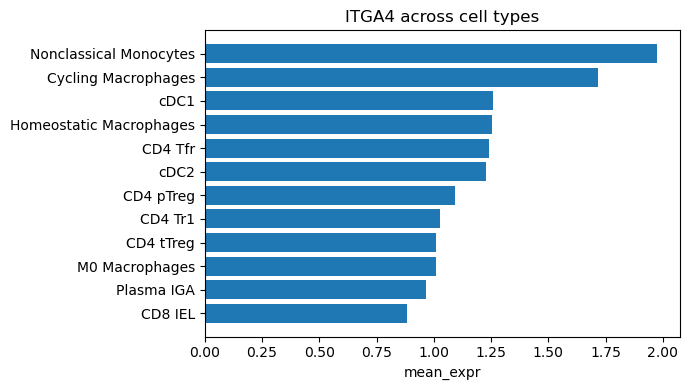

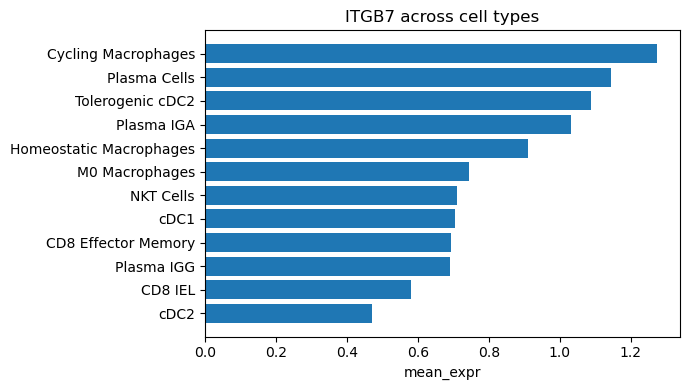

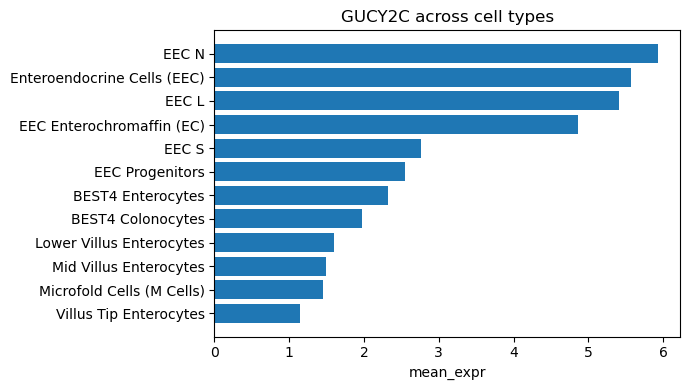

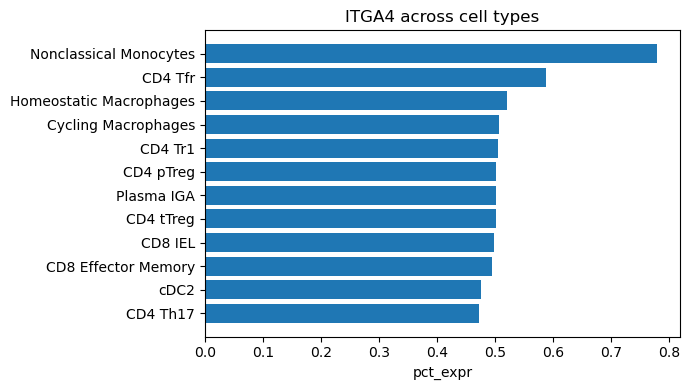

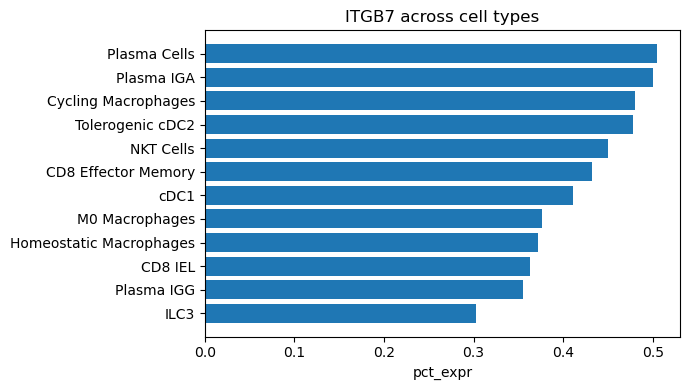

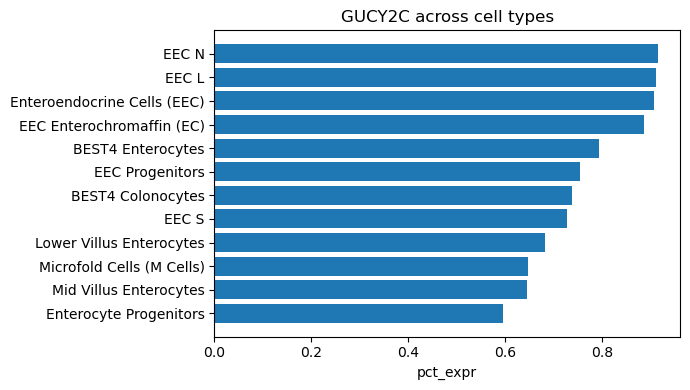

In [20]:
import matplotlib.pyplot as plt

def plot_top_celltypes_for_gene(df, gene_symbol, top_n=12, sort_by="mean_expr"):
    sub = df[df["gene_symbol"] == gene_symbol].copy()
    if sub.empty:
        print(f"No data for {gene_symbol}")
        return

    sub = sub.sort_values(sort_by, ascending=False).head(top_n).iloc[::-1]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(sub["cell_type"], sub[sort_by])
    ax.set_title(f"{gene_symbol} across cell types")
    ax.set_xlabel(sort_by)
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

for g in ["ITGA4", "ITGB7", "GUCY2C"]:
    plot_top_celltypes_for_gene(positive_control_expr, g, top_n=12, sort_by="mean_expr")
    
for g in ["ITGA4", "ITGB7", "GUCY2C"]:
    plot_top_celltypes_for_gene(positive_control_expr, g, top_n=12, sort_by="pct_expr")

In [21]:
POSITIVE_CONTROL_PROGRAMS = {
    "vedolizumab_targets": ["ITGA4", "ITGB7"],
    "linaclotide_targets": ["GUCY2C"],
}

def get_symbol_matrix(adata, symbols, gene_symbol_col=GENE_SYMBOL_COL, layer=None):
    gs = adata.var[gene_symbol_col].astype(str)
    idx = np.where(gs.isin(symbols).values)[0]
    found_symbols = gs.iloc[idx].tolist()

    if layer is None:
        X = adata.X[:, idx]
    else:
        X = adata.layers[layer][:, idx]

    return X, idx, found_symbols

def summarize_program_by_celltype(
    adata,
    symbols,
    program_name,
    celltype_col=CELLTYPE_COL,
    gene_symbol_col=GENE_SYMBOL_COL,
    layer=None,
):
    X, idx, found_symbols = get_symbol_matrix(
        adata,
        symbols,
        gene_symbol_col=gene_symbol_col,
        layer=layer,
    )

    print(f"\nProgram: {program_name}")
    print("Requested symbols:", symbols)
    print("Found symbols:", sorted(set(found_symbols)))
    print("Number of matching features:", len(idx))

    if len(idx) == 0:
        return pd.DataFrame()

    if sparse.issparse(X):
        per_cell_score = np.asarray(X.mean(axis=1)).ravel()
    else:
        per_cell_score = X.mean(axis=1)

    df = pd.DataFrame({
        "cell_type": adata.obs[celltype_col].astype(str).values,
        "program_score": per_cell_score,
    })

    out = (
        df.groupby("cell_type", as_index=False)
        .agg(
            n_cells=("cell_type", "size"),
            mean_program_score=("program_score", "mean"),
            pct_nonzero_program=("program_score", lambda x: np.mean(np.asarray(x) > 0)),
        )
        .sort_values("mean_program_score", ascending=False)
        .reset_index(drop=True)
    )
    out.insert(0, "program", program_name)
    return out

vedo_prog = summarize_program_by_celltype(
    adata,
    POSITIVE_CONTROL_PROGRAMS["vedolizumab_targets"],
    "vedolizumab_targets",
)

lina_prog = summarize_program_by_celltype(
    adata,
    POSITIVE_CONTROL_PROGRAMS["linaclotide_targets"],
    "linaclotide_targets",
)

display(vedo_prog.head(15))
display(lina_prog.head(15))


Program: vedolizumab_targets
Requested symbols: ['ITGA4', 'ITGB7']
Found symbols: ['ITGA4', 'ITGB7']
Number of matching features: 2

Program: linaclotide_targets
Requested symbols: ['GUCY2C']
Found symbols: ['GUCY2C']
Number of matching features: 1


,program,cell_type,n_cells,mean_program_score,pct_nonzero_program
0,vedolizumab_targets,Cycling Macrophages,1136,1.495599,0.659331
1,vedolizumab_targets,Homeostatic Macrophages,5613,1.080973,0.629432
2,vedolizumab_targets,Plasma IGA,31875,0.998243,0.725114
3,vedolizumab_targets,Nonclassical Monocytes,250,0.992000,0.780000
4,vedolizumab_targets,cDC1,1052,0.981464,0.603612
5,vedolizumab_targets,Plasma Cells,38083,0.972652,0.704304
6,vedolizumab_targets,Tolerogenic cDC2,316,0.969937,0.607595
7,vedolizumab_targets,M0 Macrophages,12307,0.875843,0.593077
8,vedolizumab_targets,cDC2,4792,0.850167,0.579299
9,vedolizumab_targets,CD8 Effector Memory,12263,0.765514,0.699992


,program,cell_type,n_cells,mean_program_score,pct_nonzero_program
0,linaclotide_targets,EEC N,593,5.927487,0.915683
1,linaclotide_targets,Enteroendocrine Cells (EEC),195,5.574359,0.907692
2,linaclotide_targets,EEC L,473,5.405920,0.911205
3,linaclotide_targets,EEC Enterochromaffin (EC),956,4.860879,0.887029
4,linaclotide_targets,EEC S,177,2.762712,0.728814
5,linaclotide_targets,EEC Progenitors,546,2.543956,0.754579
6,linaclotide_targets,BEST4 Enterocytes,2691,2.318841,0.793385
7,linaclotide_targets,BEST4 Colonocytes,6154,1.974813,0.738057
8,linaclotide_targets,Lower Villus Enterocytes,18149,1.593752,0.682186
9,linaclotide_targets,Mid Villus Enterocytes,30619,1.497044,0.644534


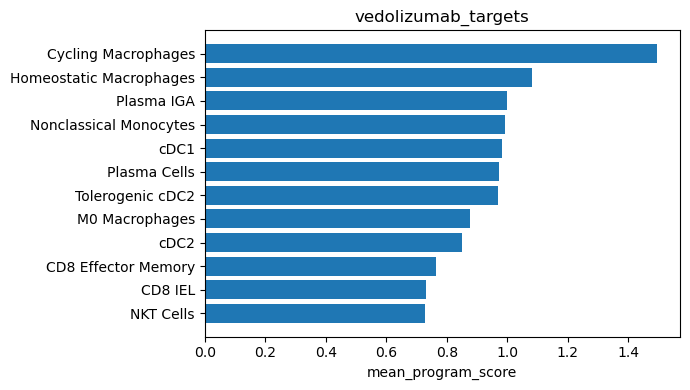

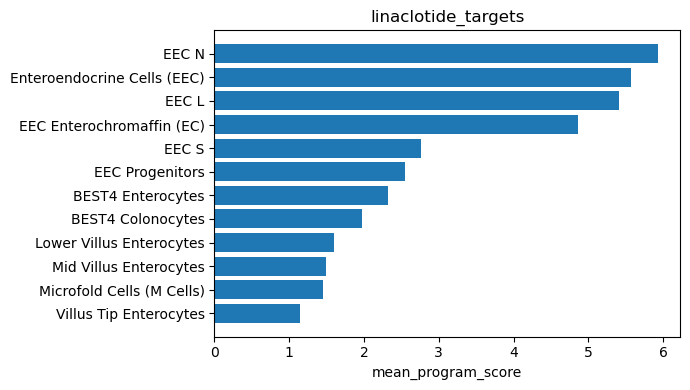

In [22]:
def plot_program(df, top_n=12, score_col="mean_program_score"):
    if df.empty:
        print("Empty dataframe")
        return

    program_name = df["program"].iloc[0]
    sub = df.sort_values(score_col, ascending=False).head(top_n).iloc[::-1]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(sub["cell_type"], sub[score_col])
    ax.set_title(program_name)
    ax.set_xlabel(score_col)
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

plot_program(vedo_prog, top_n=12)
plot_program(lina_prog, top_n=12)

In [23]:
print("Top vedolizumab program cell types:")
display(vedo_prog.head(10))

print("\nTop linaclotide program cell types:")
display(lina_prog.head(10))

Top vedolizumab program cell types:


,program,cell_type,n_cells,mean_program_score,pct_nonzero_program
0,vedolizumab_targets,Cycling Macrophages,1136,1.495599,0.659331
1,vedolizumab_targets,Homeostatic Macrophages,5613,1.080973,0.629432
2,vedolizumab_targets,Plasma IGA,31875,0.998243,0.725114
3,vedolizumab_targets,Nonclassical Monocytes,250,0.992000,0.780000
4,vedolizumab_targets,cDC1,1052,0.981464,0.603612
5,vedolizumab_targets,Plasma Cells,38083,0.972652,0.704304
6,vedolizumab_targets,Tolerogenic cDC2,316,0.969937,0.607595
7,vedolizumab_targets,M0 Macrophages,12307,0.875843,0.593077
8,vedolizumab_targets,cDC2,4792,0.850167,0.579299
9,vedolizumab_targets,CD8 Effector Memory,12263,0.765514,0.699992



Top linaclotide program cell types:


,program,cell_type,n_cells,mean_program_score,pct_nonzero_program
0,linaclotide_targets,EEC N,593,5.927487,0.915683
1,linaclotide_targets,Enteroendocrine Cells (EEC),195,5.574359,0.907692
2,linaclotide_targets,EEC L,473,5.405920,0.911205
3,linaclotide_targets,EEC Enterochromaffin (EC),956,4.860879,0.887029
4,linaclotide_targets,EEC S,177,2.762712,0.728814
5,linaclotide_targets,EEC Progenitors,546,2.543956,0.754579
6,linaclotide_targets,BEST4 Enterocytes,2691,2.318841,0.793385
7,linaclotide_targets,BEST4 Colonocytes,6154,1.974813,0.738057
8,linaclotide_targets,Lower Villus Enterocytes,18149,1.593752,0.682186
9,linaclotide_targets,Mid Villus Enterocytes,30619,1.497044,0.644534


# IDEA: aggregate scores across drugs for one DISEASE at a time from openTargets, point to historical drug x celltype popularity that way

In [37]:
import requests
import pandas as pd
import numpy as np
from pprint import pprint

OT_URL = "https://api.platform.opentargets.org/api/v4/graphql"

def run_gql(query, variables=None):
    r = requests.post(
        OT_URL,
        json={"query": query, "variables": variables or {}},
        timeout=60,
    )

    try:
        payload = r.json()
    except Exception:
        payload = {"raw_text": r.text}

    if not r.ok:
        print("HTTP status:", r.status_code)
        print("Variables:")
        pprint(variables or {})
        print("Response payload:")
        pprint(payload)
        r.raise_for_status()

    if "errors" in payload:
        print("GraphQL errors:")
        pprint(payload["errors"])
        raise RuntimeError(payload["errors"])

    return payload["data"]

In [25]:
search_query = """
query SearchEverything($q: String!) {
  search(queryString: $q) {
    total
    hits {
      id
      entity
      name
      description
    }
  }
}
"""

disease_terms = [
    "diarrhea",
    "colorectal cancer",
    "Crohn disease",
    "ulcerative colitis",
]

search_results = {}

for term in disease_terms:
    data = run_gql(search_query, {"q": term})
    hits = data["search"]["hits"]
    df = pd.DataFrame(hits)
    search_results[term] = df

    print(f"\n{'=' * 80}")
    print(f"Search term: {term}")
    print(f"Returned hits: {len(df)}")
    if df.empty:
        print("No hits")
        continue

    if "entity" in df.columns:
        print("\nEntity counts:")
        print(df["entity"].value_counts(dropna=False))

    cols = [c for c in ["id", "entity", "name", "description"] if c in df.columns]
    display(df[cols].head(20))


Search term: diarrhea
Returned hits: 25

Entity counts:
entity
disease    14
target     10
study       1
Name: count, dtype: int64


,id,entity,name,description
0,HP_0002014,disease,Diarrhea,Abnormally increased frequency (usually define...
1,MONDO_0001673,disease,diarrheal disease,The condition of having at least three loose o...
2,ENSG00000167306,target,MYO5B,myosin VB
3,ENSG00000091138,target,SLC26A3,solute carrier family 26 member 3
4,ENSG00000122859,target,NEUROG3,neurogenin 3
5,ENSG00000167642,target,SPINT2,"serine peptidase inhibitor, Kunitz type 2"
6,ENSG00000066230,target,SLC9A3,solute carrier family 9 member A3
7,ENSG00000284229,target,MIR6848,microRNA 6848
8,ENSG00000185000,target,DGAT1,diacylglycerol O-acyltransferase 1
9,ENSG00000166900,target,STX3,syntaxin 3



Search term: colorectal cancer
Returned hits: 25

Entity counts:
entity
study      21
disease     4
Name: count, dtype: int64


,id,entity,name,description
0,MONDO_0005575,disease,colorectal cancer,A primary or metastatic malignant neoplasm tha...
1,EFO_1001951,disease,colorectal carcinoma,A malignant epithelial neoplasm that arises fr...
2,MONDO_0012132,disease,"colorectal cancer, susceptibility to, 1",Any colorectal cancer in which the cause of th...
3,MONDO_0023113,disease,familial colorectal cancer,Familial colon cancer is a cluster of colon ca...
4,GCST90435268,study,GCST90435268,None
5,GCST007992,study,GCST007992,None
6,GCST90018808,study,GCST90018808,None
7,GCST90018588,study,GCST90018588,None
8,GCST90308753,study,GCST90308753,None
9,GCST007552,study,GCST007552,None



Search term: Crohn disease
Returned hits: 25

Entity counts:
entity
study      18
disease     7
Name: count, dtype: int64


,id,entity,name,description
0,EFO_0000384,disease,Crohn's disease,A gastrointestinal disorder characterized by c...
1,MONDO_0009960,disease,inflammatory bowel disease 1,Any inflammatory bowel disease in which the ca...
2,EFO_0005629,disease,small bowel Crohn's disease,A Crohn disease involving a pathogenic inflamm...
3,EFO_0005627,disease,perianal Crohn's disease,A Crohn disease involving a pathogenic inflamm...
4,MONDO_0000710,disease,gastroduodenal Crohn disease,An inflammatory bowel disease characterized by...
5,GCST005537,study,GCST005537,None
6,GCST000955,study,GCST000955,None
7,MONDO_0000709,disease,Crohn ileitis,A Crohn disease involving a pathogenic inflamm...
8,EFO_0003767,disease,inflammatory bowel disease,A spectrum of small and large bowel inflammato...
9,GCST90446792,study,GCST90446792,None



Search term: ulcerative colitis
Returned hits: 25

Entity counts:
entity
study      22
disease     3
Name: count, dtype: int64


,id,entity,name,description
0,EFO_0000729,disease,ulcerative colitis,An inflammatory bowel disease involving the mu...
1,MONDO_0009960,disease,inflammatory bowel disease 1,Any inflammatory bowel disease in which the ca...
2,GCST90446794,study,GCST90446794,None
3,GCST90446795,study,GCST90446795,None
4,GCST004133,study,GCST004133,None
5,GCST000964,study,GCST000964,None
6,GCST90480319,study,GCST90480319,None
7,GCST90479622,study,GCST90479622,None
8,GCST90018933,study,GCST90018933,None
9,GCST001728,study,GCST001728,None


In [26]:
def filter_disease_hits(df):
    if df.empty or "entity" not in df.columns:
        return df.copy()

    entity_lower = df["entity"].astype(str).str.lower()
    keep = entity_lower.isin(["disease", "phenotype"])
    out = df.loc[keep].copy()

    cols = [c for c in ["id", "entity", "name", "description"] if c in out.columns]
    return out[cols].reset_index(drop=True)

filtered_search_results = {}

for term, df in search_results.items():
    filtered = filter_disease_hits(df)
    filtered_search_results[term] = filtered

    print(f"\n{'-' * 80}")
    print(f"Filtered disease or phenotype hits for: {term}")
    display(filtered.head(20))


--------------------------------------------------------------------------------
Filtered disease or phenotype hits for: diarrhea


,id,entity,name,description
0,HP_0002014,disease,Diarrhea,Abnormally increased frequency (usually define...
1,MONDO_0001673,disease,diarrheal disease,The condition of having at least three loose o...
2,MONDO_0012479,disease,congenital malabsorptive diarrhea 4,Congenital malabsorptive diarrhea due to pauci...
3,MONDO_0014375,disease,congenital diarrhea 7 with exudative enteropathy,Congenital chronic diarrhea with protein-losin...
4,Orphanet_84064,disease,Syndromic diarrhea,"Syndromic diarrhea (SD), or tricho-hepato-ente..."
5,HP_0002254,disease,Intermittent diarrhea,Repeated episodes of diarrhea separated by per...
6,MONDO_0008964,disease,congenital secretory chloride diarrhea 1,Any secretory diarrhea in which the cause of t...
7,MONDO_0013184,disease,congenital diarrhea 5 with tufting enteropathy,Congenital Tufting Enteropathy is a rare conge...
8,MONDO_0013825,disease,congenital diarrhea 6,Any congenital diarrhea in which the cause of ...
9,HP_0002028,disease,Chronic diarrhea,"The presence of chronic diarrhea, which is usu..."



--------------------------------------------------------------------------------
Filtered disease or phenotype hits for: colorectal cancer


,id,entity,name,description
0,MONDO_0005575,disease,colorectal cancer,A primary or metastatic malignant neoplasm tha...
1,EFO_1001951,disease,colorectal carcinoma,A malignant epithelial neoplasm that arises fr...
2,MONDO_0012132,disease,"colorectal cancer, susceptibility to, 1",Any colorectal cancer in which the cause of th...
3,MONDO_0023113,disease,familial colorectal cancer,Familial colon cancer is a cluster of colon ca...



--------------------------------------------------------------------------------
Filtered disease or phenotype hits for: Crohn disease


,id,entity,name,description
0,EFO_0000384,disease,Crohn's disease,A gastrointestinal disorder characterized by c...
1,MONDO_0009960,disease,inflammatory bowel disease 1,Any inflammatory bowel disease in which the ca...
2,EFO_0005629,disease,small bowel Crohn's disease,A Crohn disease involving a pathogenic inflamm...
3,EFO_0005627,disease,perianal Crohn's disease,A Crohn disease involving a pathogenic inflamm...
4,MONDO_0000710,disease,gastroduodenal Crohn disease,An inflammatory bowel disease characterized by...
5,MONDO_0000709,disease,Crohn ileitis,A Crohn disease involving a pathogenic inflamm...
6,EFO_0003767,disease,inflammatory bowel disease,A spectrum of small and large bowel inflammato...



--------------------------------------------------------------------------------
Filtered disease or phenotype hits for: ulcerative colitis


,id,entity,name,description
0,EFO_0000729,disease,ulcerative colitis,An inflammatory bowel disease involving the mu...
1,MONDO_0009960,disease,inflammatory bowel disease 1,Any inflammatory bowel disease in which the ca...
2,EFO_1000226,disease,Dysplasia in Ulcerative Colitis,A morphologic finding indicating the presence ...


## Query high DALY diseases in OpenTargets

In [34]:
DISEASE_IDS = {
    "diarrhea": ["HP_0002014","MONDO_0012479","MONDO_0001673",
                "MONDO_0008964", "MONDO_0000257"],
    "colorectal_cancer": ["MONDO_0005575", "EFO_1001951", "MONDO_0023113"],
    "crohn_disease": ["EFO_0000384"],
    "ulcerative_colitis": ["EFO_0000729"],
}

print("Fill these in after inspecting the search output:")
pprint(DISEASE_IDS)

Fill these in after inspecting the search output:
{'colorectal_cancer': ['MONDO_0005575', 'EFO_1001951', 'MONDO_0023113'],
 'crohn_disease': ['EFO_0000384'],
 'diarrhea': ['HP_0002014',
              'MONDO_0012479',
              'MONDO_0001673',
              'MONDO_0008964',
              'MONDO_0000257'],
 'ulcerative_colitis': ['EFO_0000729']}


In [42]:
associated_targets_query = """
query DiseaseAssociatedTargets($diseaseId: String!, $index: Int!, $size: Int!) {
  disease(efoId: $diseaseId) {
    id
    name
    associatedTargets(page: { index: $index, size: $size }) {
      count
      rows {
        score
        target {
          id
          approvedSymbol
          approvedName
        }
      }
    }
  }
}
"""


In [41]:
def fetch_associated_targets_page(disease_id, index=0, size=50):
    if not isinstance(disease_id, str):
        raise TypeError(f"disease_id must be a string here, got {type(disease_id)}")

    data = run_gql(
        associated_targets_query,
        {
            "diseaseId": disease_id,
            "index": index,
            "size": size,
        },
    )["disease"]

    if data is None:
        return pd.DataFrame(), 0

    rows = data["associatedTargets"]["rows"]
    count = data["associatedTargets"]["count"]

    out = []
    for r in rows:
        t = r["target"]
        out.append({
            "disease_id": data["id"],
            "disease_name": data["name"],
            "target_id": t["id"],
            "target_symbol": t["approvedSymbol"],
            "target_name": t["approvedName"],
            "association_score": r["score"],
            "page_index": index,
        })

    return pd.DataFrame(out), count

def fetch_all_associated_targets_single(disease_id, page_size=50, verbose=True):
    first_page, total_count = fetch_associated_targets_page(disease_id, index=0, size=page_size)

    if verbose:
        print("Disease ID:", disease_id)
        if not first_page.empty:
            print("Disease name:", first_page["disease_name"].iloc[0])
        print("Total associated targets reported:", total_count)

    if total_count == 0:
        return first_page.copy()

    all_pages = [first_page]
    n_pages = int(np.ceil(total_count / page_size))

    if verbose:
        print("Pages to fetch:", n_pages)

    for page_index in range(1, n_pages):
        page_df, _ = fetch_associated_targets_page(disease_id, index=page_index, size=page_size)
        all_pages.append(page_df)

        if verbose and (page_index < 3 or page_index == n_pages - 1):
            print(f"Fetched page {page_index + 1} of {n_pages}")

    out = pd.concat(all_pages, ignore_index=True)
    out = out.sort_values("association_score", ascending=False).reset_index(drop=True)
    return out

def fetch_all_associated_targets(disease_ids, page_size=50, verbose=True):
    if isinstance(disease_ids, str):
        return fetch_all_associated_targets_single(disease_ids, page_size=page_size, verbose=verbose)

    if isinstance(disease_ids, (list, tuple)):
        dfs = []
        for disease_id in disease_ids:
            if verbose:
                print("\n" + "-" * 80)
                print("Fetching disease term:", disease_id)
            df = fetch_all_associated_targets_single(disease_id, page_size=page_size, verbose=verbose)
            if not df.empty:
                dfs.append(df)

        if not dfs:
            return pd.DataFrame()

        combined = pd.concat(dfs, ignore_index=True)

        # Aggregate repeated targets across disease terms
        aggregated = (
            combined.groupby(["target_id", "target_symbol", "target_name"], as_index=False)
            .agg(
                association_score_max=("association_score", "max"),
                association_score_mean=("association_score", "mean"),
                n_source_terms=("disease_id", "nunique"),
                source_disease_ids=("disease_id", lambda x: sorted(set(x))),
                source_disease_names=("disease_name", lambda x: sorted(set(x))),
            )
            .sort_values(
                ["association_score_max", "association_score_mean", "n_source_terms"],
                ascending=False,
            )
            .reset_index(drop=True)
        )

        return aggregated

    raise TypeError(f"disease_ids must be str, list, or tuple; got {type(disease_ids)}")

In [46]:
from pathlib import Path
import pandas as pd

ot_cache_dir = Path("/Users/kylekimler/Projects/GCA/github_vignette_output/OpenTargetsQueries/ot_disease_target_cache")
ot_cache_dir.mkdir(exist_ok=True, parents=True)

print("Cache dir:", ot_cache_dir.resolve())

Cache dir: /Users/kylekimler/Projects/GCA/github_vignette_output/OpenTargetsQueries/ot_disease_target_cache


In [47]:
disease_target_tables = {}

for label, disease_ids in DISEASE_IDS.items():
    print("\n" + "=" * 80)
    print("Disease label:", label)
    print("Disease IDs:", disease_ids)

    if disease_ids is None:
        print("Skipping because ID is None")
        continue

    df = fetch_all_associated_targets(disease_ids, page_size=50, verbose=True)
    disease_target_tables[label] = df

    print("\nTop associated targets:")
    display(df.head(20))
    print("Rows fetched:", len(df))

    out_path = ot_cache_dir / f"{label}_associated_targets.parquet"
    df.to_parquet(out_path, index=False)
    print("Saved:", out_path)


Disease label: diarrhea
Disease IDs: ['HP_0002014', 'MONDO_0012479', 'MONDO_0001673', 'MONDO_0008964', 'MONDO_0000257']

--------------------------------------------------------------------------------
Fetching disease term: HP_0002014
Disease ID: HP_0002014
Disease name: Diarrhea
Total associated targets reported: 666
Pages to fetch: 14
Fetched page 2 of 14
Fetched page 3 of 14
Fetched page 14 of 14

--------------------------------------------------------------------------------
Fetching disease term: MONDO_0012479
Disease ID: MONDO_0012479
Disease name: congenital malabsorptive diarrhea 4
Total associated targets reported: 14
Pages to fetch: 1

--------------------------------------------------------------------------------
Fetching disease term: MONDO_0001673
Disease ID: MONDO_0001673
Disease name: diarrheal disease
Total associated targets reported: 1749
Pages to fetch: 35
Fetched page 2 of 35
Fetched page 3 of 35
Fetched page 35 of 35

-------------------------------------------

,target_id,target_symbol,target_name,association_score_max,association_score_mean,n_source_terms,source_disease_ids,source_disease_names
0,ENSG00000167306,MYO5B,myosin VB,0.846194,0.235834,3,"[HP_0002014, MONDO_0001673, MONDO_0008964]","[Diarrhea, congenital secretory chloride diarr..."
1,ENSG00000091138,SLC26A3,solute carrier family 26 member 3,0.819652,0.510103,4,"[HP_0002014, MONDO_0000257, MONDO_0001673, MON...","[Diarrhea, acute diarrhea, congenital secretor..."
2,ENSG00000119888,EPCAM,epithelial cell adhesion molecule,0.759108,0.276059,3,"[HP_0002014, MONDO_0001673, MONDO_0008964]","[Diarrhea, congenital secretory chloride diarr..."
3,ENSG00000070019,GUCY2C,guanylate cyclase 2C,0.746876,0.351650,4,"[HP_0002014, MONDO_0000257, MONDO_0001673, MON...","[Diarrhea, acute diarrhea, congenital secretor..."
4,ENSG00000167642,SPINT2,"serine peptidase inhibitor, Kunitz type 2",0.730726,0.370907,2,"[HP_0002014, MONDO_0001673]","[Diarrhea, diarrheal disease]"
5,ENSG00000185000,DGAT1,diacylglycerol O-acyltransferase 1,0.694738,0.420175,3,"[HP_0002014, MONDO_0001673, MONDO_0008964]","[Diarrhea, congenital secretory chloride diarr..."
6,ENSG00000122859,NEUROG3,neurogenin 3,0.676565,0.454170,3,"[HP_0002014, MONDO_0001673, MONDO_0012479]","[Diarrhea, congenital malabsorptive diarrhea 4..."
7,ENSG00000134245,WNT2B,Wnt family member 2B,0.672780,0.338700,2,"[HP_0002014, MONDO_0001673]","[Diarrhea, diarrheal disease]"
8,ENSG00000066230,SLC9A3,solute carrier family 9 member A3,0.652113,0.187875,4,"[HP_0002014, MONDO_0001673, MONDO_0008964, MON...","[Diarrhea, congenital malabsorptive diarrhea 4..."
9,ENSG00000112038,OPRM1,opioid receptor mu 1,0.601347,0.485463,2,"[HP_0002014, MONDO_0001673]","[Diarrhea, diarrheal disease]"


Rows fetched: 1839
Saved: /Users/kylekimler/Projects/GCA/github_vignette_output/OpenTargetsQueries/ot_disease_target_cache/diarrhea_associated_targets.parquet

Disease label: colorectal_cancer
Disease IDs: ['MONDO_0005575', 'EFO_1001951', 'MONDO_0023113']

--------------------------------------------------------------------------------
Fetching disease term: MONDO_0005575
Disease ID: MONDO_0005575
Disease name: colorectal cancer
Total associated targets reported: 14396
Pages to fetch: 288
Fetched page 2 of 288
Fetched page 3 of 288
Fetched page 288 of 288

--------------------------------------------------------------------------------
Fetching disease term: EFO_1001951
Disease ID: EFO_1001951
Disease name: colorectal carcinoma
Total associated targets reported: 12237
Pages to fetch: 245
Fetched page 2 of 245
Fetched page 3 of 245
Fetched page 245 of 245

--------------------------------------------------------------------------------
Fetching disease term: MONDO_0023113
Disease ID: MO

,target_id,target_symbol,target_name,association_score_max,association_score_mean,n_source_terms,source_disease_ids,source_disease_names
0,ENSG00000095002,MSH2,mutS homolog 2,0.924764,0.881678,3,"[EFO_1001951, MONDO_0005575, MONDO_0023113]","[colorectal cancer, colorectal carcinoma, fami..."
1,ENSG00000116062,MSH6,mutS homolog 6,0.916007,0.860636,3,"[EFO_1001951, MONDO_0005575, MONDO_0023113]","[colorectal cancer, colorectal carcinoma, fami..."
2,ENSG00000076242,MLH1,mutL homolog 1,0.914821,0.865805,3,"[EFO_1001951, MONDO_0005575, MONDO_0023113]","[colorectal cancer, colorectal carcinoma, fami..."
3,ENSG00000122512,PMS2,"PMS1 homolog 2, mismatch repair system component",0.882414,0.814376,3,"[EFO_1001951, MONDO_0005575, MONDO_0023113]","[colorectal cancer, colorectal carcinoma, fami..."
4,ENSG00000134982,APC,APC regulator of Wnt signaling pathway,0.859741,0.642242,3,"[EFO_1001951, MONDO_0005575, MONDO_0023113]","[colorectal cancer, colorectal carcinoma, fami..."
5,ENSG00000141510,TP53,tumor protein p53,0.833255,0.689666,3,"[EFO_1001951, MONDO_0005575, MONDO_0023113]","[colorectal cancer, colorectal carcinoma, fami..."
6,ENSG00000121879,PIK3CA,"phosphatidylinositol-4,5-bisphosphate 3-kinase...",0.816969,0.543236,3,"[EFO_1001951, MONDO_0005575, MONDO_0023113]","[colorectal cancer, colorectal carcinoma, fami..."
7,ENSG00000133703,KRAS,"KRAS proto-oncogene, GTPase",0.809663,0.548578,3,"[EFO_1001951, MONDO_0005575, MONDO_0023113]","[colorectal cancer, colorectal carcinoma, fami..."
8,ENSG00000157764,BRAF,"B-Raf proto-oncogene, serine/threonine kinase",0.789709,0.521669,3,"[EFO_1001951, MONDO_0005575, MONDO_0023113]","[colorectal cancer, colorectal carcinoma, fami..."
9,ENSG00000141646,SMAD4,SMAD family member 4,0.788199,0.545247,3,"[EFO_1001951, MONDO_0005575, MONDO_0023113]","[colorectal cancer, colorectal carcinoma, fami..."


Rows fetched: 13842
Saved: /Users/kylekimler/Projects/GCA/github_vignette_output/OpenTargetsQueries/ot_disease_target_cache/colorectal_cancer_associated_targets.parquet

Disease label: crohn_disease
Disease IDs: ['EFO_0000384']

--------------------------------------------------------------------------------
Fetching disease term: EFO_0000384
Disease ID: EFO_0000384
Disease name: Crohn's disease
Total associated targets reported: 6575
Pages to fetch: 132
Fetched page 2 of 132
Fetched page 3 of 132
Fetched page 132 of 132

Top associated targets:


,target_id,target_symbol,target_name,association_score_max,association_score_mean,n_source_terms,source_disease_ids,source_disease_names
0,ENSG00000167207,NOD2,nucleotide binding oligomerization domain cont...,0.793768,0.793768,1,[EFO_0000384],[Crohn's disease]
1,ENSG00000113302,IL12B,interleukin 12B,0.713089,0.713089,1,[EFO_0000384],[Crohn's disease]
2,ENSG00000115232,ITGA4,integrin subunit alpha 4,0.712973,0.712973,1,[EFO_0000384],[Crohn's disease]
3,ENSG00000136634,IL10,interleukin 10,0.637782,0.637782,1,[EFO_0000384],[Crohn's disease]
4,ENSG00000232810,TNF,tumor necrosis factor,0.627464,0.627464,1,[EFO_0000384],[Crohn's disease]
5,ENSG00000113580,NR3C1,nuclear receptor subfamily 3 group C member 1,0.609618,0.609618,1,[EFO_0000384],[Crohn's disease]
6,ENSG00000139626,ITGB7,integrin subunit beta 7,0.605727,0.605727,1,[EFO_0000384],[Crohn's disease]
7,ENSG00000162594,IL23R,interleukin 23 receptor,0.575331,0.575331,1,[EFO_0000384],[Crohn's disease]
8,ENSG00000096968,JAK2,Janus kinase 2,0.561402,0.561402,1,[EFO_0000384],[Crohn's disease]
9,ENSG00000105397,TYK2,tyrosine kinase 2,0.555519,0.555519,1,[EFO_0000384],[Crohn's disease]


Rows fetched: 6345
Saved: /Users/kylekimler/Projects/GCA/github_vignette_output/OpenTargetsQueries/ot_disease_target_cache/crohn_disease_associated_targets.parquet

Disease label: ulcerative_colitis
Disease IDs: ['EFO_0000729']

--------------------------------------------------------------------------------
Fetching disease term: EFO_0000729
Disease ID: EFO_0000729
Disease name: ulcerative colitis
Total associated targets reported: 9376
Pages to fetch: 188
Fetched page 2 of 188
Fetched page 3 of 188
Fetched page 188 of 188

Top associated targets:


,target_id,target_symbol,target_name,association_score_max,association_score_mean,n_source_terms,source_disease_ids,source_disease_names
0,ENSG00000232810,TNF,tumor necrosis factor,0.637689,0.637689,1,[EFO_0000729],[ulcerative colitis]
1,ENSG00000132170,PPARG,peroxisome proliferator activated receptor gamma,0.631392,0.631392,1,[EFO_0000729],[ulcerative colitis]
2,ENSG00000113302,IL12B,interleukin 12B,0.628716,0.628716,1,[EFO_0000729],[ulcerative colitis]
3,ENSG00000167207,NOD2,nucleotide binding oligomerization domain cont...,0.626770,0.626770,1,[EFO_0000729],[ulcerative colitis]
4,ENSG00000073756,PTGS2,prostaglandin-endoperoxide synthase 2,0.625632,0.625632,1,[EFO_0000729],[ulcerative colitis]
5,ENSG00000113580,NR3C1,nuclear receptor subfamily 3 group C member 1,0.618273,0.618273,1,[EFO_0000729],[ulcerative colitis]
6,ENSG00000095303,PTGS1,prostaglandin-endoperoxide synthase 1,0.614345,0.614345,1,[EFO_0000729],[ulcerative colitis]
7,ENSG00000012779,ALOX5,arachidonate 5-lipoxygenase,0.609951,0.609951,1,[EFO_0000729],[ulcerative colitis]
8,ENSG00000139626,ITGB7,integrin subunit beta 7,0.603893,0.603893,1,[EFO_0000729],[ulcerative colitis]
9,ENSG00000115232,ITGA4,integrin subunit alpha 4,0.598034,0.598034,1,[EFO_0000729],[ulcerative colitis]


Rows fetched: 8869
Saved: /Users/kylekimler/Projects/GCA/github_vignette_output/OpenTargetsQueries/ot_disease_target_cache/ulcerative_colitis_associated_targets.parquet


In [50]:
def standardize_disease_target_df(df, disease_label):
    df = df.copy()

    if "association_score" in df.columns:
        df["association_score_max"] = df["association_score"]
        df["association_score_mean"] = df["association_score"]
        df["n_source_terms"] = 1
        df["source_disease_ids"] = df["disease_id"].apply(lambda x: [x])
        df["source_disease_names"] = df["disease_name"].apply(lambda x: [x])

    df["disease_label"] = disease_label

    keep_cols = [
        "disease_label",
        "target_id",
        "target_symbol",
        "target_name",
        "association_score_max",
        "association_score_mean",
        "n_source_terms",
        "source_disease_ids",
        "source_disease_names",
    ]

    out = df[keep_cols].copy()

    dedup_cols = [
        "disease_label",
        "target_id",
        "target_symbol",
        "target_name",
        "association_score_max",
        "association_score_mean",
        "n_source_terms",
    ]

    out = out.drop_duplicates(subset=dedup_cols).reset_index(drop=True)
    return out

disease_target_df = pd.concat(
    [standardize_disease_target_df(df, label) for label, df in disease_target_tables.items()],
    ignore_index=True,
)

display(disease_target_df.head(20))
print(disease_target_df.shape)

,disease_label,target_id,target_symbol,target_name,association_score_max,association_score_mean,n_source_terms,source_disease_ids,source_disease_names
0,diarrhea,ENSG00000167306,MYO5B,myosin VB,0.846194,0.235834,3,"[HP_0002014, MONDO_0001673, MONDO_0008964]","[Diarrhea, congenital secretory chloride diarr..."
1,diarrhea,ENSG00000091138,SLC26A3,solute carrier family 26 member 3,0.819652,0.510103,4,"[HP_0002014, MONDO_0000257, MONDO_0001673, MON...","[Diarrhea, acute diarrhea, congenital secretor..."
2,diarrhea,ENSG00000119888,EPCAM,epithelial cell adhesion molecule,0.759108,0.276059,3,"[HP_0002014, MONDO_0001673, MONDO_0008964]","[Diarrhea, congenital secretory chloride diarr..."
3,diarrhea,ENSG00000070019,GUCY2C,guanylate cyclase 2C,0.746876,0.351650,4,"[HP_0002014, MONDO_0000257, MONDO_0001673, MON...","[Diarrhea, acute diarrhea, congenital secretor..."
4,diarrhea,ENSG00000167642,SPINT2,"serine peptidase inhibitor, Kunitz type 2",0.730726,0.370907,2,"[HP_0002014, MONDO_0001673]","[Diarrhea, diarrheal disease]"
5,diarrhea,ENSG00000185000,DGAT1,diacylglycerol O-acyltransferase 1,0.694738,0.420175,3,"[HP_0002014, MONDO_0001673, MONDO_0008964]","[Diarrhea, congenital secretory chloride diarr..."
6,diarrhea,ENSG00000122859,NEUROG3,neurogenin 3,0.676565,0.454170,3,"[HP_0002014, MONDO_0001673, MONDO_0012479]","[Diarrhea, congenital malabsorptive diarrhea 4..."
7,diarrhea,ENSG00000134245,WNT2B,Wnt family member 2B,0.672780,0.338700,2,"[HP_0002014, MONDO_0001673]","[Diarrhea, diarrheal disease]"
8,diarrhea,ENSG00000066230,SLC9A3,solute carrier family 9 member A3,0.652113,0.187875,4,"[HP_0002014, MONDO_0001673, MONDO_0008964, MON...","[Diarrhea, congenital malabsorptive diarrhea 4..."
9,diarrhea,ENSG00000112038,OPRM1,opioid receptor mu 1,0.601347,0.485463,2,"[HP_0002014, MONDO_0001673]","[Diarrhea, diarrheal disease]"


(30895, 9)


In [51]:
disease_target_df = pd.concat(
    [standardize_disease_target_df(df, label) for label, df in disease_target_tables.items()],
    ignore_index=True,
)


combined_path = ot_cache_dir / "combined_disease_target_df.parquet"
disease_target_df.to_parquet(combined_path, index=False)

print("Saved combined file:", combined_path)
print(disease_target_df.shape)
display(disease_target_df.head(20))

Saved combined file: /Users/kylekimler/Projects/GCA/github_vignette_output/OpenTargetsQueries/ot_disease_target_cache/combined_disease_target_df.parquet
(30895, 9)


,disease_label,target_id,target_symbol,target_name,association_score_max,association_score_mean,n_source_terms,source_disease_ids,source_disease_names
0,diarrhea,ENSG00000167306,MYO5B,myosin VB,0.846194,0.235834,3,"[HP_0002014, MONDO_0001673, MONDO_0008964]","[Diarrhea, congenital secretory chloride diarr..."
1,diarrhea,ENSG00000091138,SLC26A3,solute carrier family 26 member 3,0.819652,0.510103,4,"[HP_0002014, MONDO_0000257, MONDO_0001673, MON...","[Diarrhea, acute diarrhea, congenital secretor..."
2,diarrhea,ENSG00000119888,EPCAM,epithelial cell adhesion molecule,0.759108,0.276059,3,"[HP_0002014, MONDO_0001673, MONDO_0008964]","[Diarrhea, congenital secretory chloride diarr..."
3,diarrhea,ENSG00000070019,GUCY2C,guanylate cyclase 2C,0.746876,0.351650,4,"[HP_0002014, MONDO_0000257, MONDO_0001673, MON...","[Diarrhea, acute diarrhea, congenital secretor..."
4,diarrhea,ENSG00000167642,SPINT2,"serine peptidase inhibitor, Kunitz type 2",0.730726,0.370907,2,"[HP_0002014, MONDO_0001673]","[Diarrhea, diarrheal disease]"
5,diarrhea,ENSG00000185000,DGAT1,diacylglycerol O-acyltransferase 1,0.694738,0.420175,3,"[HP_0002014, MONDO_0001673, MONDO_0008964]","[Diarrhea, congenital secretory chloride diarr..."
6,diarrhea,ENSG00000122859,NEUROG3,neurogenin 3,0.676565,0.454170,3,"[HP_0002014, MONDO_0001673, MONDO_0012479]","[Diarrhea, congenital malabsorptive diarrhea 4..."
7,diarrhea,ENSG00000134245,WNT2B,Wnt family member 2B,0.672780,0.338700,2,"[HP_0002014, MONDO_0001673]","[Diarrhea, diarrheal disease]"
8,diarrhea,ENSG00000066230,SLC9A3,solute carrier family 9 member A3,0.652113,0.187875,4,"[HP_0002014, MONDO_0001673, MONDO_0008964, MON...","[Diarrhea, congenital malabsorptive diarrhea 4..."
9,diarrhea,ENSG00000112038,OPRM1,opioid receptor mu 1,0.601347,0.485463,2,"[HP_0002014, MONDO_0001673]","[Diarrhea, diarrheal disease]"


## Analyze OpenTargets data

In [ ]:
# Reload OT data for our 4 diseases

combined_path = ot_cache_dir / "combined_disease_target_df.parquet"
disease_target_df = pd.read_parquet(combined_path)

print(disease_target_df.shape)
display(disease_target_df.head())

In [ ]:
# Reload anndata if you haven't loaded yet

# adata = sc.read_h5ad("/Users/kylekimler/Projects/GCA/meta_datasets/integrated-objects/hgca_all_lineages_v1.h5ad")


In [53]:
print("\nTargets per disease label:")
print(
    disease_target_df.groupby("disease_label")["target_symbol"]
    .nunique()
    .sort_values(ascending=False)
)

for label, sub in disease_target_df.groupby("disease_label"):
    print("\n" + "-" * 80)
    print(label)
    display(
        sub.sort_values("association_score_max", ascending=False)[
            ["target_symbol", "target_name", "association_score_max", "n_source_terms"]
        ].head(20)
    )


Targets per disease label:
disease_label
colorectal_cancer     13773
ulcerative_colitis     8825
crohn_disease          6332
diarrhea               1836
Name: target_symbol, dtype: int64

--------------------------------------------------------------------------------
colorectal_cancer


,target_symbol,target_name,association_score_max,n_source_terms
1839,MSH2,mutS homolog 2,0.924764,3
1840,MSH6,mutS homolog 6,0.916007,3
1841,MLH1,mutL homolog 1,0.914821,3
1842,PMS2,"PMS1 homolog 2, mismatch repair system component",0.882414,3
1843,APC,APC regulator of Wnt signaling pathway,0.859741,3
1844,TP53,tumor protein p53,0.833255,3
1845,PIK3CA,"phosphatidylinositol-4,5-bisphosphate 3-kinase...",0.816969,3
1846,KRAS,"KRAS proto-oncogene, GTPase",0.809663,3
1847,BRAF,"B-Raf proto-oncogene, serine/threonine kinase",0.789709,3
1848,SMAD4,SMAD family member 4,0.788199,3



--------------------------------------------------------------------------------
crohn_disease


,target_symbol,target_name,association_score_max,n_source_terms
15681,NOD2,nucleotide binding oligomerization domain cont...,0.793768,1
15682,IL12B,interleukin 12B,0.713089,1
15683,ITGA4,integrin subunit alpha 4,0.712973,1
15684,IL10,interleukin 10,0.637782,1
15685,TNF,tumor necrosis factor,0.627464,1
15686,NR3C1,nuclear receptor subfamily 3 group C member 1,0.609618,1
15687,ITGB7,integrin subunit beta 7,0.605727,1
15688,IL23R,interleukin 23 receptor,0.575331,1
15689,JAK2,Janus kinase 2,0.561402,1
15690,TYK2,tyrosine kinase 2,0.555519,1



--------------------------------------------------------------------------------
diarrhea


,target_symbol,target_name,association_score_max,n_source_terms
0,MYO5B,myosin VB,0.846194,3
1,SLC26A3,solute carrier family 26 member 3,0.819652,4
2,EPCAM,epithelial cell adhesion molecule,0.759108,3
3,GUCY2C,guanylate cyclase 2C,0.746876,4
4,SPINT2,"serine peptidase inhibitor, Kunitz type 2",0.730726,2
5,DGAT1,diacylglycerol O-acyltransferase 1,0.694738,3
6,NEUROG3,neurogenin 3,0.676565,3
7,WNT2B,Wnt family member 2B,0.672780,2
8,SLC9A3,solute carrier family 9 member A3,0.652113,4
9,OPRM1,opioid receptor mu 1,0.601347,2



--------------------------------------------------------------------------------
ulcerative_colitis


,target_symbol,target_name,association_score_max,n_source_terms
22026,TNF,tumor necrosis factor,0.637689,1
22027,PPARG,peroxisome proliferator activated receptor gamma,0.631392,1
22028,IL12B,interleukin 12B,0.628716,1
22029,NOD2,nucleotide binding oligomerization domain cont...,0.626770,1
22030,PTGS2,prostaglandin-endoperoxide synthase 2,0.625632,1
22031,NR3C1,nuclear receptor subfamily 3 group C member 1,0.618273,1
22032,PTGS1,prostaglandin-endoperoxide synthase 1,0.614345,1
22033,ALOX5,arachidonate 5-lipoxygenase,0.609951,1
22034,ITGB7,integrin subunit beta 7,0.603893,1
22035,ITGA4,integrin subunit alpha 4,0.598034,1


In [54]:
CELLTYPE_COL = "hgca_celltype_v1"
GENE_SYMBOL_COL = "gene_symbol"

adata_symbols = (
    adata.var[GENE_SYMBOL_COL]
    .astype(str)
    .replace("", np.nan)
    .dropna()
)

adata_symbol_set = set(adata_symbols)

overlap_summary = []

for disease_label, sub in disease_target_df.groupby("disease_label"):
    target_symbols = set(sub["target_symbol"].dropna().astype(str))
    overlap = target_symbols & adata_symbol_set
    overlap_summary.append({
        "disease_label": disease_label,
        "n_targets_ot": len(target_symbols),
        "n_targets_in_adata": len(overlap),
        "mapping_rate": len(overlap) / len(target_symbols) if len(target_symbols) else np.nan,
    })

overlap_summary = pd.DataFrame(overlap_summary).sort_values("mapping_rate", ascending=False)
display(overlap_summary)

,disease_label,n_targets_ot,n_targets_in_adata,mapping_rate
2,diarrhea,1836,1767,0.962418
0,colorectal_cancer,13773,12840,0.932259
3,ulcerative_colitis,8825,8036,0.910595
1,crohn_disease,6332,5689,0.898452


In [55]:
gene_symbol_series = adata.var[GENE_SYMBOL_COL].astype(str)

symbol_to_idx = {}
for i, sym in enumerate(gene_symbol_series):
    if sym and sym != "nan":
        symbol_to_idx.setdefault(sym, []).append(i)

print("Unique mapped symbols in adata:", len(symbol_to_idx))
print("Example duplicated symbols:")
dup_example = {k: v for k, v in symbol_to_idx.items() if len(v) > 1}
print(list(dup_example.items())[:10])

Unique mapped symbols in adata: 35564
Example duplicated symbols:
[('MATR3', [357, 32767]), ('GGT1', [2148, 33724]), ('CYB561D2', [4239, 30825]), ('TMSB15B', [10053, 30299]), ('HSPA14', [15784, 33105]), ('GOLGA8M', [16032, 28651]), ('LINC01505', [21886, 21915]), ('LINC01238', [23037, 28496]), ('ARMCX5-GPRASP2', [30691, 33844]), ('TBCE', [33206, 33248])]


In [56]:
ot_in_adata = disease_target_df.copy()
ot_in_adata["target_symbol"] = ot_in_adata["target_symbol"].astype(str)

ot_in_adata = ot_in_adata[ot_in_adata["target_symbol"].isin(symbol_to_idx)].copy()

print("Rows after symbol matching:", ot_in_adata.shape[0])
display(ot_in_adata.head(10))

Rows after symbol matching: 28373


,target_id,target_symbol,target_name,association_score_max,association_score_mean,n_source_terms,source_disease_ids,source_disease_names,disease_label
0,ENSG00000167306,MYO5B,myosin VB,0.846194,0.235834,3,"[HP_0002014, MONDO_0001673, MONDO_0008964]","[Diarrhea, congenital secretory chloride diarr...",diarrhea
1,ENSG00000091138,SLC26A3,solute carrier family 26 member 3,0.819652,0.510103,4,"[HP_0002014, MONDO_0000257, MONDO_0001673, MON...","[Diarrhea, acute diarrhea, congenital secretor...",diarrhea
2,ENSG00000119888,EPCAM,epithelial cell adhesion molecule,0.759108,0.276059,3,"[HP_0002014, MONDO_0001673, MONDO_0008964]","[Diarrhea, congenital secretory chloride diarr...",diarrhea
3,ENSG00000070019,GUCY2C,guanylate cyclase 2C,0.746876,0.351650,4,"[HP_0002014, MONDO_0000257, MONDO_0001673, MON...","[Diarrhea, acute diarrhea, congenital secretor...",diarrhea
4,ENSG00000167642,SPINT2,"serine peptidase inhibitor, Kunitz type 2",0.730726,0.370907,2,"[HP_0002014, MONDO_0001673]","[Diarrhea, diarrheal disease]",diarrhea
5,ENSG00000185000,DGAT1,diacylglycerol O-acyltransferase 1,0.694738,0.420175,3,"[HP_0002014, MONDO_0001673, MONDO_0008964]","[Diarrhea, congenital secretory chloride diarr...",diarrhea
6,ENSG00000122859,NEUROG3,neurogenin 3,0.676565,0.454170,3,"[HP_0002014, MONDO_0001673, MONDO_0012479]","[Diarrhea, congenital malabsorptive diarrhea 4...",diarrhea
7,ENSG00000134245,WNT2B,Wnt family member 2B,0.672780,0.338700,2,"[HP_0002014, MONDO_0001673]","[Diarrhea, diarrheal disease]",diarrhea
8,ENSG00000066230,SLC9A3,solute carrier family 9 member A3,0.652113,0.187875,4,"[HP_0002014, MONDO_0001673, MONDO_0008964, MON...","[Diarrhea, congenital malabsorptive diarrhea 4...",diarrhea
9,ENSG00000112038,OPRM1,opioid receptor mu 1,0.601347,0.485463,2,"[HP_0002014, MONDO_0001673]","[Diarrhea, diarrheal disease]",diarrhea


In [57]:
expanded_rows = []

for _, row in ot_in_adata.iterrows():
    symbol = row["target_symbol"]
    idxs = symbol_to_idx.get(symbol, [])
    for var_idx in idxs:
        expanded_rows.append({
            "disease_label": row["disease_label"],
            "target_id": row["target_id"],
            "target_symbol": symbol,
            "target_name": row["target_name"],
            "association_score_max": row["association_score_max"],
            "association_score_mean": row["association_score_mean"],
            "n_source_terms": row["n_source_terms"],
            "var_idx": var_idx,
        })

ot_feature_df = pd.DataFrame(expanded_rows)

print("Expanded rows:", ot_feature_df.shape)
display(ot_feature_df.head(10))

Expanded rows: (28385, 8)


,disease_label,target_id,target_symbol,target_name,association_score_max,association_score_mean,n_source_terms,var_idx
0,diarrhea,ENSG00000167306,MYO5B,myosin VB,0.846194,0.235834,3,11863
1,diarrhea,ENSG00000091138,SLC26A3,solute carrier family 26 member 3,0.819652,0.510103,4,1903
2,diarrhea,ENSG00000119888,EPCAM,epithelial cell adhesion molecule,0.759108,0.276059,3,4919
3,diarrhea,ENSG00000070019,GUCY2C,guanylate cyclase 2C,0.746876,0.351650,4,1084
4,diarrhea,ENSG00000167642,SPINT2,"serine peptidase inhibitor, Kunitz type 2",0.730726,0.370907,2,11942
5,diarrhea,ENSG00000185000,DGAT1,diacylglycerol O-acyltransferase 1,0.694738,0.420175,3,15264
6,diarrhea,ENSG00000122859,NEUROG3,neurogenin 3,0.676565,0.454170,3,5258
7,diarrhea,ENSG00000134245,WNT2B,Wnt family member 2B,0.672780,0.338700,2,6752
8,diarrhea,ENSG00000066230,SLC9A3,solute carrier family 9 member A3,0.652113,0.187875,4,956
9,diarrhea,ENSG00000112038,OPRM1,opioid receptor mu 1,0.601347,0.485463,2,3948


In [58]:
feature_indices = ot_feature_df["var_idx"].astype(int).unique()
feature_indices = np.sort(feature_indices)

print("Number of matched adata features:", len(feature_indices))

X = adata.X[:, feature_indices]
celltypes = adata.obs[CELLTYPE_COL].astype(str).values

if sparse.issparse(X):
    print("Using sparse matrix")
else:
    print("Using dense matrix")

Number of matched adata features: 14817
Using sparse matrix


In [59]:
unique_celltypes = pd.Index(sorted(pd.unique(celltypes)))
celltype_to_mask = {ct: (celltypes == ct) for ct in unique_celltypes}

mean_expr_by_ct = []
pct_expr_by_ct = []

for ct in unique_celltypes:
    mask = celltype_to_mask[ct]
    X_ct = X[mask, :]

    if sparse.issparse(X_ct):
        mean_expr = np.asarray(X_ct.mean(axis=0)).ravel()
        pct_expr = np.asarray((X_ct > 0).mean(axis=0)).ravel()
    else:
        mean_expr = X_ct.mean(axis=0)
        pct_expr = (X_ct > 0).mean(axis=0)

    mean_expr_by_ct.append(mean_expr)
    pct_expr_by_ct.append(pct_expr)

mean_expr_by_ct = pd.DataFrame(
    np.vstack(mean_expr_by_ct),
    index=unique_celltypes,
    columns=feature_indices,
)

pct_expr_by_ct = pd.DataFrame(
    np.vstack(pct_expr_by_ct),
    index=unique_celltypes,
    columns=feature_indices,
)

print(mean_expr_by_ct.shape)
print(pct_expr_by_ct.shape)
display(mean_expr_by_ct.iloc[:5, :5])

(94, 14817)
(94, 14817)


,0,1,2,3,5
Adipocytes,0.147458,0.010169,0.440678,0.032203,0.010169
Angiogenic Pericytes,0.053872,0.001122,0.246914,0.051627,0.001122
Arteriolar Endothelial,0.201161,0.013540,0.248549,0.038685,0.147969
BEST4 Colonocytes,0.690608,0.004387,0.422164,0.139747,0.000650
BEST4 Enterocytes,0.388703,0.001115,0.316983,0.139725,0.001115


In [60]:
feature_meta = (
    ot_feature_df[
        [
            "disease_label",
            "target_id",
            "target_symbol",
            "target_name",
            "association_score_max",
            "association_score_mean",
            "n_source_terms",
            "var_idx",
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

display(feature_meta.head(10))

,disease_label,target_id,target_symbol,target_name,association_score_max,association_score_mean,n_source_terms,var_idx
0,diarrhea,ENSG00000167306,MYO5B,myosin VB,0.846194,0.235834,3,11863
1,diarrhea,ENSG00000091138,SLC26A3,solute carrier family 26 member 3,0.819652,0.510103,4,1903
2,diarrhea,ENSG00000119888,EPCAM,epithelial cell adhesion molecule,0.759108,0.276059,3,4919
3,diarrhea,ENSG00000070019,GUCY2C,guanylate cyclase 2C,0.746876,0.351650,4,1084
4,diarrhea,ENSG00000167642,SPINT2,"serine peptidase inhibitor, Kunitz type 2",0.730726,0.370907,2,11942
5,diarrhea,ENSG00000185000,DGAT1,diacylglycerol O-acyltransferase 1,0.694738,0.420175,3,15264
6,diarrhea,ENSG00000122859,NEUROG3,neurogenin 3,0.676565,0.454170,3,5258
7,diarrhea,ENSG00000134245,WNT2B,Wnt family member 2B,0.672780,0.338700,2,6752
8,diarrhea,ENSG00000066230,SLC9A3,solute carrier family 9 member A3,0.652113,0.187875,4,956
9,diarrhea,ENSG00000112038,OPRM1,opioid receptor mu 1,0.601347,0.485463,2,3948


In [61]:
burden_rows = []

for disease_label, sub in feature_meta.groupby("disease_label"):
    sub = sub.copy()

    var_idxs = sub["var_idx"].astype(int).tolist()
    weights = sub["association_score_max"].astype(float).values

    mean_mat = mean_expr_by_ct[var_idxs]
    pct_mat = pct_expr_by_ct[var_idxs]

    for ct in mean_mat.index:
        mean_vals = mean_mat.loc[ct].values.astype(float)
        pct_vals = pct_mat.loc[ct].values.astype(float)

        burden_rows.append({
            "disease_label": disease_label,
            "cell_type": ct,
            "n_features": len(var_idxs),
            "n_unique_targets": sub["target_symbol"].nunique(),
            "weighted_mean_expr_burden": np.average(mean_vals, weights=weights) if len(weights) else np.nan,
            "weighted_pct_expr_burden": np.average(pct_vals, weights=weights) if len(weights) else np.nan,
            "weighted_sum_expr_burden": np.sum(mean_vals * weights),
            "weighted_sum_pct_burden": np.sum(pct_vals * weights),
        })

celltype_disease_burden_df = pd.DataFrame(burden_rows)
display(celltype_disease_burden_df.head(20))

,disease_label,cell_type,n_features,n_unique_targets,weighted_mean_expr_burden,weighted_pct_expr_burden,weighted_sum_expr_burden,weighted_sum_pct_burden
0,colorectal_cancer,Adipocytes,12870,12840,0.759093,0.177582,652.270781,152.591750
1,colorectal_cancer,Angiogenic Pericytes,12870,12840,0.461127,0.140563,396.235555,120.782147
2,colorectal_cancer,Arteriolar Endothelial,12870,12840,0.547887,0.156622,470.786795,134.581853
3,colorectal_cancer,BEST4 Colonocytes,12870,12840,2.016385,0.226263,1732.631945,194.422436
4,colorectal_cancer,BEST4 Enterocytes,12870,12840,1.561100,0.205321,1341.416672,176.427398
5,colorectal_cancer,Brunners Gland Cells,12870,12840,2.625956,0.295512,2256.422407,253.926303
6,colorectal_cancer,CD4 Memory,12870,12840,0.386313,0.111073,331.949757,95.442316
7,colorectal_cancer,CD4 Naive,12870,12840,0.401146,0.108036,344.694954,92.832842
8,colorectal_cancer,CD4 Tfh,12870,12840,0.374798,0.111954,322.055288,96.199612
9,colorectal_cancer,CD4 Tfr,12870,12840,0.417441,0.125311,358.696950,107.676943


In [62]:
for disease_label, sub in celltype_disease_burden_df.groupby("disease_label"):
    print("\n" + "=" * 80)
    print(disease_label)
    display(
        sub.sort_values("weighted_mean_expr_burden", ascending=False)
        .head(20)
        .reset_index(drop=True)
    )


colorectal_cancer


,disease_label,cell_type,n_features,n_unique_targets,weighted_mean_expr_burden,weighted_pct_expr_burden,weighted_sum_expr_burden,weighted_sum_pct_burden
0,colorectal_cancer,Colonocyte Progenitors,12870,12840,2.705902,0.293958,2325.118536,252.591303
1,colorectal_cancer,Foveolar Cells,12870,12840,2.643054,0.220187,2271.114484,189.201203
2,colorectal_cancer,Brunners Gland Cells,12870,12840,2.625956,0.295512,2256.422407,253.926303
3,colorectal_cancer,Microfold Cells (M Cells),12870,12840,2.562556,0.270239,2201.944679,232.210356
4,colorectal_cancer,Enterocyte Progenitors,12870,12840,2.554107,0.278548,2194.683814,239.350117
5,colorectal_cancer,Mid Crypt Colonocytes,12870,12840,2.521099,0.243515,2166.321445,209.246772
6,colorectal_cancer,Lower Villus Enterocytes,12870,12840,2.438693,0.243380,2095.512069,209.130802
7,colorectal_cancer,Transiently Amplifying Cells (TA),12870,12840,2.426168,0.272098,2084.748929,233.807182
8,colorectal_cancer,Secretory Progenitors,12870,12840,2.409555,0.282842,2070.473902,243.039186
9,colorectal_cancer,Intestinal Stem Cells (ISC),12870,12840,2.349841,0.242516,2019.163602,208.388332



crohn_disease


,disease_label,cell_type,n_features,n_unique_targets,weighted_mean_expr_burden,weighted_pct_expr_burden,weighted_sum_expr_burden,weighted_sum_pct_burden
0,crohn_disease,Paneth Cells,5694,5689,1.476716,0.132077,313.115415,28.004985
1,crohn_disease,Plasma IGA,5694,5689,1.339787,0.124583,284.081646,26.415864
2,crohn_disease,EEC N,5694,5689,1.193657,0.140546,253.097016,29.800623
3,crohn_disease,Plasma IGG,5694,5689,1.088661,0.119646,230.834117,25.369103
4,crohn_disease,Colonocyte Progenitors,5694,5689,0.992873,0.204322,210.523716,43.323499
5,crohn_disease,Microfold Cells (M Cells),5694,5689,0.992636,0.207391,210.473535,43.974140
6,crohn_disease,Foveolar Cells,5694,5689,0.986283,0.167314,209.126435,35.476495
7,crohn_disease,EEC S,5694,5689,0.959652,0.171372,203.479805,36.336779
8,crohn_disease,Brunners Gland Cells,5694,5689,0.956150,0.205007,202.737194,43.468583
9,crohn_disease,Secretory Progenitors,5694,5689,0.913052,0.192168,193.598971,40.746259



diarrhea


,disease_label,cell_type,n_features,n_unique_targets,weighted_mean_expr_burden,weighted_pct_expr_burden,weighted_sum_expr_burden,weighted_sum_pct_burden
0,diarrhea,Foveolar Cells,1771,1767,3.068903,0.234191,157.187932,11.995186
1,diarrhea,Crypt Top Colonocytes,1771,1767,2.208463,0.230473,113.116534,11.804720
2,diarrhea,Secretory Progenitors,1771,1767,2.190795,0.242703,112.211596,12.431160
3,diarrhea,Brunners Gland Cells,1771,1767,1.993912,0.247766,102.127329,12.690473
4,diarrhea,Lower Villus Enterocytes,1771,1767,1.883210,0.265375,96.457210,13.592389
5,diarrhea,Microfold Cells (M Cells),1771,1767,1.867634,0.244909,95.659417,12.544152
6,diarrhea,EEC S,1771,1767,1.831943,0.260126,93.831384,13.323567
7,diarrhea,Enterocyte Progenitors,1771,1767,1.830571,0.250978,93.761071,12.855006
8,diarrhea,Mid Crypt Colonocytes,1771,1767,1.809336,0.250672,92.673435,12.839301
9,diarrhea,Transiently Amplifying Cells (TA),1771,1767,1.717987,0.237926,87.994595,12.186472



ulcerative_colitis


,disease_label,cell_type,n_features,n_unique_targets,weighted_mean_expr_burden,weighted_pct_expr_burden,weighted_sum_expr_burden,weighted_sum_pct_burden
0,ulcerative_colitis,Paneth Cells,8050,8036,2.290715,0.142554,710.045249,44.186931
1,ulcerative_colitis,Foveolar Cells,8050,8036,1.618315,0.174578,501.623435,54.113474
2,ulcerative_colitis,Colonocyte Progenitors,8050,8036,1.493533,0.220112,462.945273,68.227447
3,ulcerative_colitis,Microfold Cells (M Cells),8050,8036,1.493194,0.214337,462.840236,66.437192
4,ulcerative_colitis,Brunners Gland Cells,8050,8036,1.456999,0.220311,451.620997,68.289060
5,ulcerative_colitis,Enterocyte Progenitors,8050,8036,1.456625,0.207281,451.504926,64.250063
6,ulcerative_colitis,Secretory Progenitors,8050,8036,1.420104,0.208577,440.184913,64.652043
7,ulcerative_colitis,Mid Crypt Colonocytes,8050,8036,1.411810,0.191717,437.613810,59.425999
8,ulcerative_colitis,Transiently Amplifying Cells (TA),8050,8036,1.399073,0.198991,433.666022,61.680447
9,ulcerative_colitis,Lower Villus Enterocytes,8050,8036,1.366839,0.190560,423.674435,59.067094


In [63]:
burden_matrix_mean = celltype_disease_burden_df.pivot(
    index="cell_type",
    columns="disease_label",
    values="weighted_mean_expr_burden",
)

burden_matrix_pct = celltype_disease_burden_df.pivot(
    index="cell_type",
    columns="disease_label",
    values="weighted_pct_expr_burden",
)

display(burden_matrix_mean.head())
display(burden_matrix_pct.head())

disease_label,colorectal_cancer,crohn_disease,diarrhea,ulcerative_colitis
cell_type,,,,
Adipocytes,0.759093,0.537756,0.363526,0.620424
Angiogenic Pericytes,0.461127,0.263979,0.176231,0.318990
Arteriolar Endothelial,0.547887,0.295861,0.213233,0.371354
BEST4 Colonocytes,2.016385,0.733606,1.540624,1.161609
BEST4 Enterocytes,1.561100,0.562353,1.256885,0.917023


disease_label,colorectal_cancer,crohn_disease,diarrhea,ulcerative_colitis
cell_type,,,,
Adipocytes,0.177582,0.125962,0.096559,0.137870
Angiogenic Pericytes,0.140563,0.096822,0.077562,0.105318
Arteriolar Endothelial,0.156622,0.112381,0.087455,0.118280
BEST4 Colonocytes,0.226263,0.165283,0.218033,0.176181
BEST4 Enterocytes,0.205321,0.152302,0.210741,0.160472


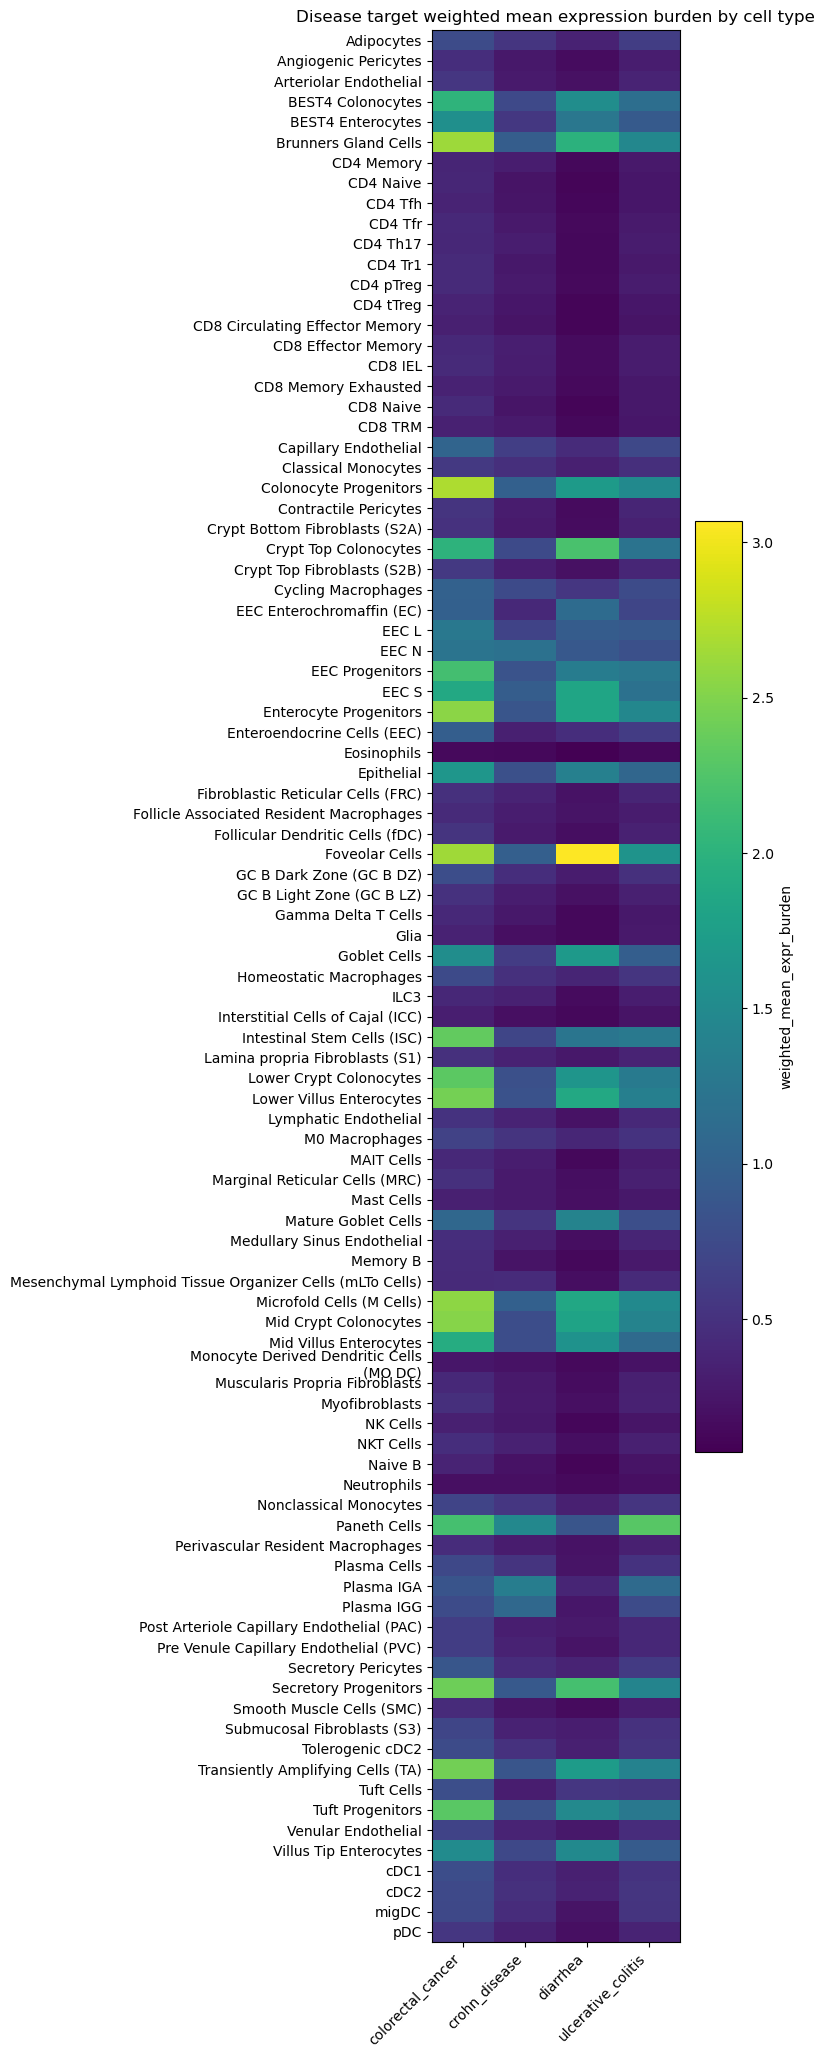

In [64]:
import matplotlib.pyplot as plt

plot_df = burden_matrix_mean.fillna(0).copy()

fig, ax = plt.subplots(figsize=(8, max(6, 0.22 * plot_df.shape[0])))
im = ax.imshow(plot_df.values, aspect="auto")

ax.set_xticks(np.arange(plot_df.shape[1]))
ax.set_xticklabels(plot_df.columns, rotation=45, ha="right")

ax.set_yticks(np.arange(plot_df.shape[0]))
ax.set_yticklabels(plot_df.index)

ax.set_title("Disease target weighted mean expression burden by cell type")
fig.colorbar(im, ax=ax, label="weighted_mean_expr_burden")
plt.tight_layout()
plt.show()

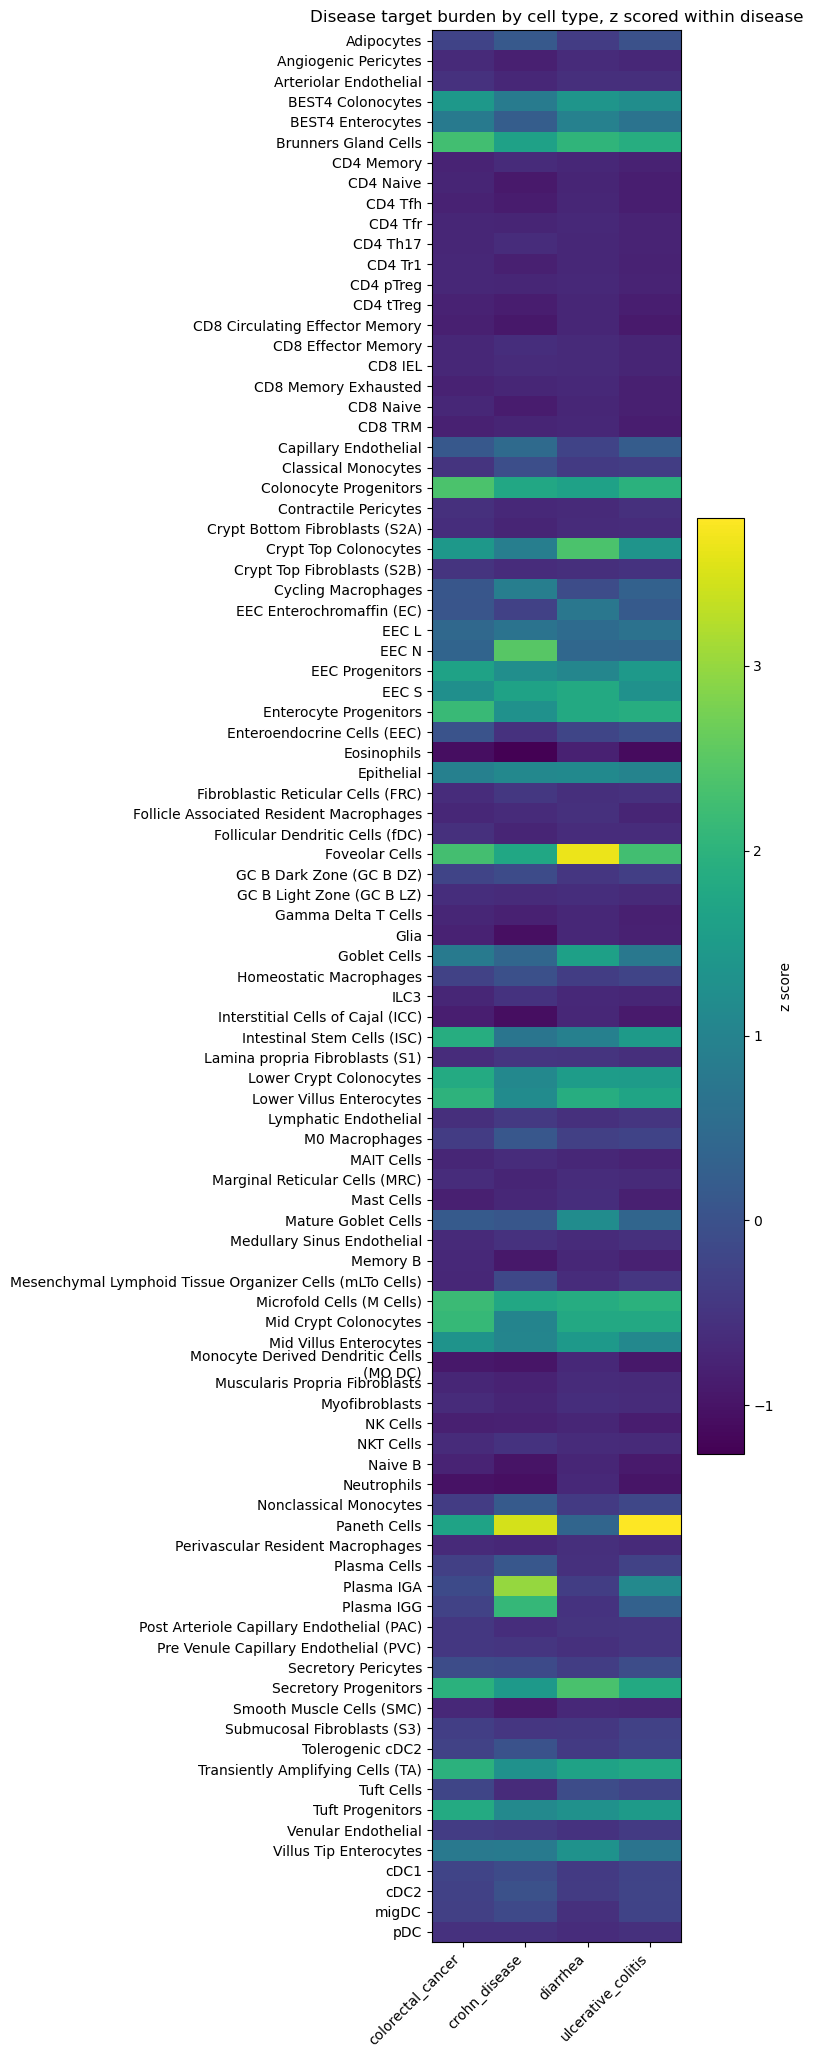

In [67]:
burden_matrix_mean_z = burden_matrix_mean.copy()

for col in burden_matrix_mean_z.columns:
    vals = burden_matrix_mean_z[col].astype(float)
    burden_matrix_mean_z[col] = (vals - vals.mean()) / vals.std(ddof=0)

plot_df = burden_matrix_mean_z.fillna(0).copy()

fig, ax = plt.subplots(figsize=(8, max(6, 0.22 * plot_df.shape[0])))
im = ax.imshow(plot_df.values, aspect="auto")

ax.set_xticks(np.arange(plot_df.shape[1]))
ax.set_xticklabels(plot_df.columns, rotation=45, ha="right")

ax.set_yticks(np.arange(plot_df.shape[0]))
ax.set_yticklabels(plot_df.index)

ax.set_title("Disease target burden by cell type, z scored within disease")
fig.colorbar(im, ax=ax, label="z score")
plt.tight_layout()
plt.show()

/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_77023/674440650.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(CELLTYPE_COL)[LEVEL2_COL]
/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_77023/674440650.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_sizes = row_annot.groupby("celltype_level2").size()


NameError: name 'style_axes_box' is not defined

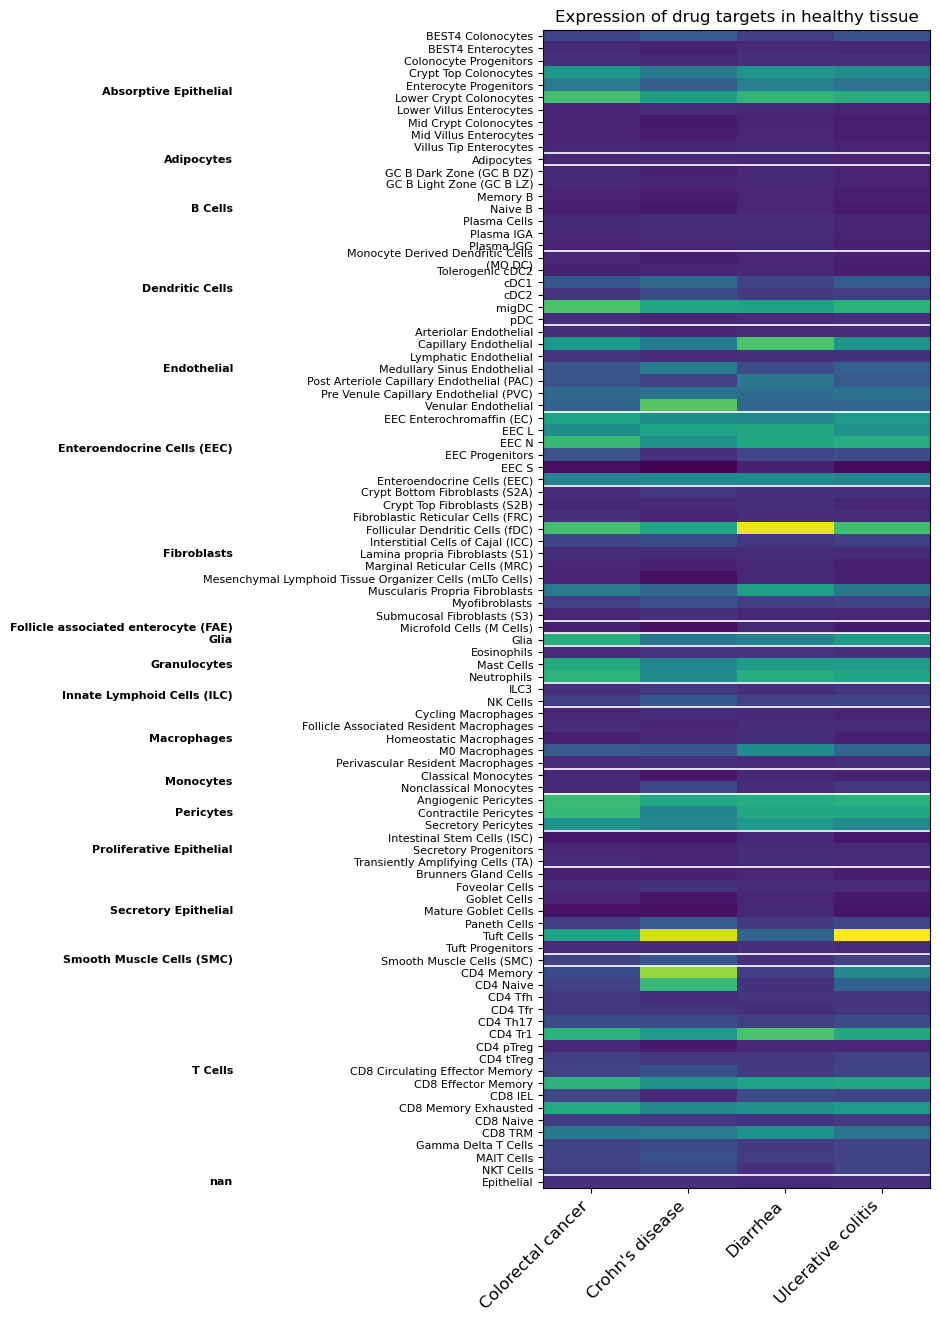

In [83]:
fig, ax = plt.subplots(figsize=(5, 0.16 * burden_matrix_mean_z.shape[0]))

im = ax.imshow(
    burden_matrix_mean_z.fillna(0).values,
    aspect="auto",
    cmap="viridis"
)


LEVEL2_COL = "hgca_celltype_level2"

celltype_level2 = (
    adata.obs[[CELLTYPE_COL, LEVEL2_COL]]
    .dropna()
    .drop_duplicates()
    .groupby(CELLTYPE_COL)[LEVEL2_COL]
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={LEVEL2_COL: "celltype_level2", CELLTYPE_COL: "cell_type"})
)

row_annot = (
    pd.DataFrame({"cell_type": burden_matrix_mean_z.index})
    .merge(celltype_level2, on="cell_type", how="left")
)

# row_annot["celltype_level2"] = row_annot["celltype_level2"].fillna("Unknown")

order = row_annot.sort_values(["celltype_level2", "cell_type"]).index
burden_plot = burden_matrix_mean_z.iloc[order]
row_annot = row_annot.iloc[order].reset_index(drop=True)

DISEASE_ORDER = ["diarrhea", "colorectal_cancer", "crohns_disease", "ulcerative_colitis"]
DISEASE_DISPLAY = {
    "diarrhea": "Diarrhea",
    "colorectal_cancer": "Colorectal cancer",
    "crohn_disease": "Crohn's disease",
    "ulcerative_colitis": "Ulcerative colitis",
}

ax.set_xticks(np.arange(burden_matrix_mean_z.shape[1]))
ax.set_xticklabels([DISEASE_DISPLAY[c] for c in burden_matrix_mean_z.columns], rotation=45, ha="right")
ax.tick_params(axis="x", labelsize=12)

ax.set_yticks(np.arange(burden_plot.shape[0]))
ax.set_yticklabels(row_annot["cell_type"], fontsize=8)

ax.set_title("Expression of drug targets in healthy tissue")

group_sizes = row_annot.groupby("celltype_level2").size()
boundaries = np.cumsum(group_sizes.values)[:-1]

for b in boundaries:
    ax.axhline(b - 0.5, color="white", linewidth=1.2)

group_centers = np.cumsum(group_sizes.values) - group_sizes.values / 2 - 0.5
for center, label in zip(group_centers, group_sizes.index):
    ax.text(
        -0.8,
        center,
        label,
        va="center",
        ha="right",
        fontsize=8,
        fontweight="bold",
        transform=ax.get_yaxis_transform()
    )

style_axes_box(ax)

cbar = fig.colorbar(im, ax=ax, pad=0.1, location="bottom")
cbar.set_label("Weighted mean expression burden")

plt.tight_layout()
plt.show()

fig.savefig(f"{OUT_DIR}_Healthy_Target_Expression.png", dpi=400, bbox_inches="tight")